# **Análisis de los resultados**

En esta sección se analizan la calidad de los ángulos optimos calculados tranfiriéndolos sobre diferentes tamaños de instancias para los 3 preentrenos realizados para profundidades $p = 1, 2, \dots, 10$.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit

import numpy as np
import pandas as pd

import math

import warnings
warnings.filterwarnings('ignore')

In [79]:
sns.set_theme(style="whitegrid", context = "notebook")
#PALETTE = sns.color_palette("tab10", 10) 
PALETTE = sns.color_palette("mako", 15) 
PALETTE = PALETTE[5:15]

In [80]:
n_cols = 2
n_rows = 5

In [81]:
def scaling_function(x, alpha):
    return 1/(2**(alpha*x))

In [82]:
def show_data(infile:str, outfile: str, min_method: str, training_set_length:int):
    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(8, 15),
        sharey = 'row', sharex = 'col'
    )
    axes_flat = axes.flatten()

    for p in range(1, 11):
        idx = p - 1 
        ax = axes_flat[idx]
        color = PALETTE[idx]

        nelder_df = pd.read_csv(f"{infile}{p}.csv")

        #Tomo las probabilidades donde se ha encontrado vectores mejores
        nel_prob_positive = nelder_df[nelder_df["P(|vnew - t|^2 < |b_op - t|^2)"] > 0.0]

        #lattice_dimension = nel_prob_positive["Lattice_dimension"].to_numpy()
        probs = nel_prob_positive["P(|vnew - t|^2 < |b_op - t|^2)"].to_numpy()

        #dimension_exacta = np.log2(nel_prob_positive["N"].to_numpy())/np.log2(np.log2(nel_prob_positive["N"].to_numpy()))
        log2_N = np.fromiter((math.log2(int(x)) for x in nel_prob_positive["N"]),
                     dtype=float, count=len(nel_prob_positive))
        dimension_exacta = log2_N / np.log2(log2_N)


        ax.scatter(
            dimension_exacta, probs,
            color=color, s=20, zorder=2,
            edgecolor = 'none', alpha = 0.7
            
        )

        alpha = curve_fit(scaling_function, xdata = dimension_exacta, ydata = probs)[0][0]
    
    
        step_size = .1
        xs = np.arange(start=2, stop=19+step_size, step=step_size)
        ys_successful = [scaling_function(x, alpha) for x in xs]

        sns.lineplot(x=xs, y=ys_successful, color='#1a1a1a', ax=ax, label=f'$\\alpha={alpha:.3f}$', zorder = 4, linewidth = 2.5)

        #sns.lineplot(x=xs, y=ys_successful, color='#1a1a1a', ax=ax,  zorder = 4, linewidth = 2.5)


        ax.set_title(rf"$p = {p}$", fontsize=13, fontweight="bold")
        ax.set_xticks(np.arange(0, 21, 5))

        ax.set_yscale("log")
        ax.set_ylim(1e-6, 1.5)
        ax.set_yticks([10**i for i in range(0, -6, -1)])
        ax.legend(fontsize=10, loc="lower left")
        #ax.text(0.05, 0.05, f'$\\alpha={alpha:.3f}$', transform=ax.transAxes, fontsize=11, verticalalignment='bottom', bbox=dict(boxstyle='round,pad=0.3', edgecolor='none', facecolor='gray', alpha=0.1))
        

    fig.suptitle(
        "Probability to improve the solution $b_{op}$\nTraining set length = "+ f"{training_set_length}" + "\n $\mathbf{" + min_method + "}$",
        y=0.94
    )

    fig.supylabel(
        r'$P(|v_{new} - t|^2 < |b_{op} - t|^2)$',
        fontsize=12,
        x=0.02  # ajusta la distancia horizontal al borde izquierdo
    )
    fig.supxlabel(
        r'Lattice Dimension $= (l \cdot \log_2(N))/\log_2(\log_2(N))$',
        fontsize=12,
        y=0.07  
    )

    fig.savefig(outfile, dpi=300, bbox_inches='tight')

    plt.show()



## **Entrenamiento 1**

### Conjunto de datos de 1210 elementos

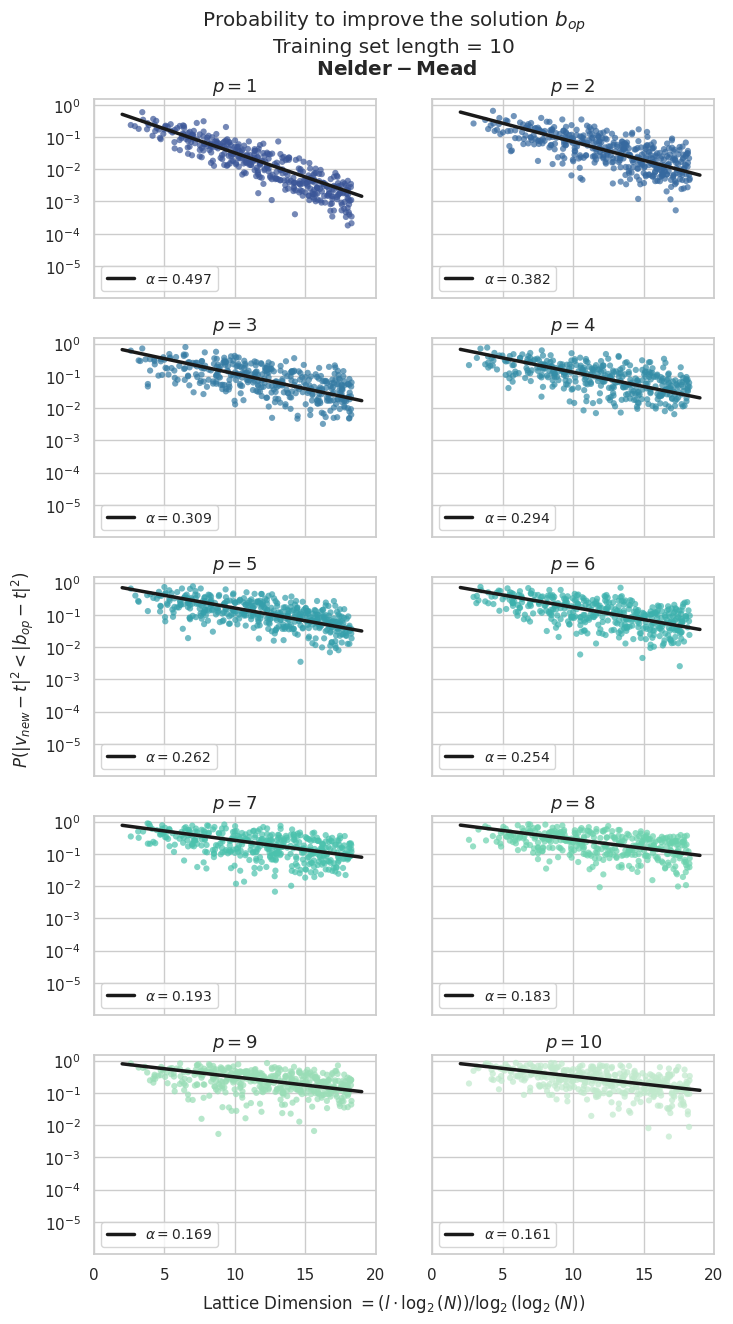

In [83]:
show_data(infile = "./results/scalability_results/datas1210_from8to128_1_NelderMead_p", 
        outfile = "./figures/scalability_datas1210_from8to128_1_NelderMead.png",
        min_method = "Nelder-Mead", training_set_length=10)

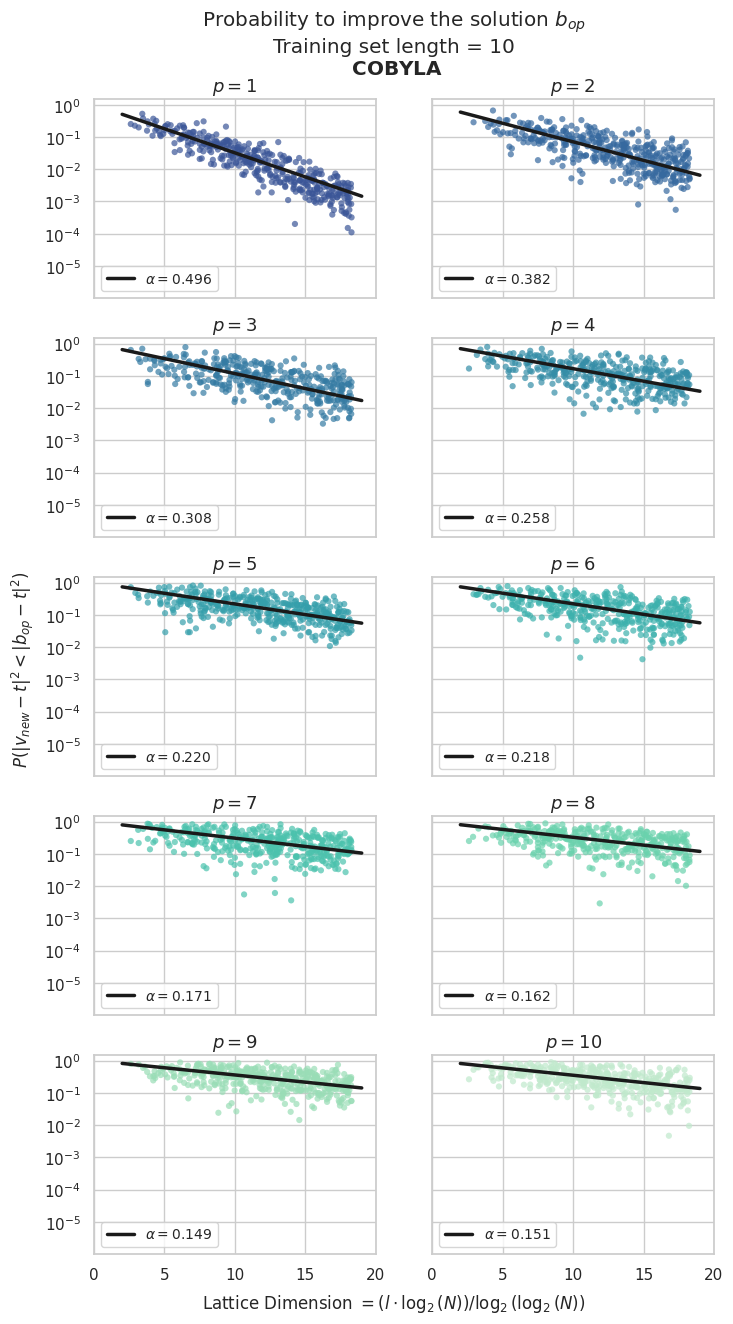

In [84]:
show_data(infile = "./results/scalability_results/datas1210_from8to128_1_COBYLA_p", 
        outfile = "./figures/scalability_datas1210_from8to128_1_COBYLA.png",
        min_method = "COBYLA", training_set_length=10)

### Conjunto de datos de 2400 elementos

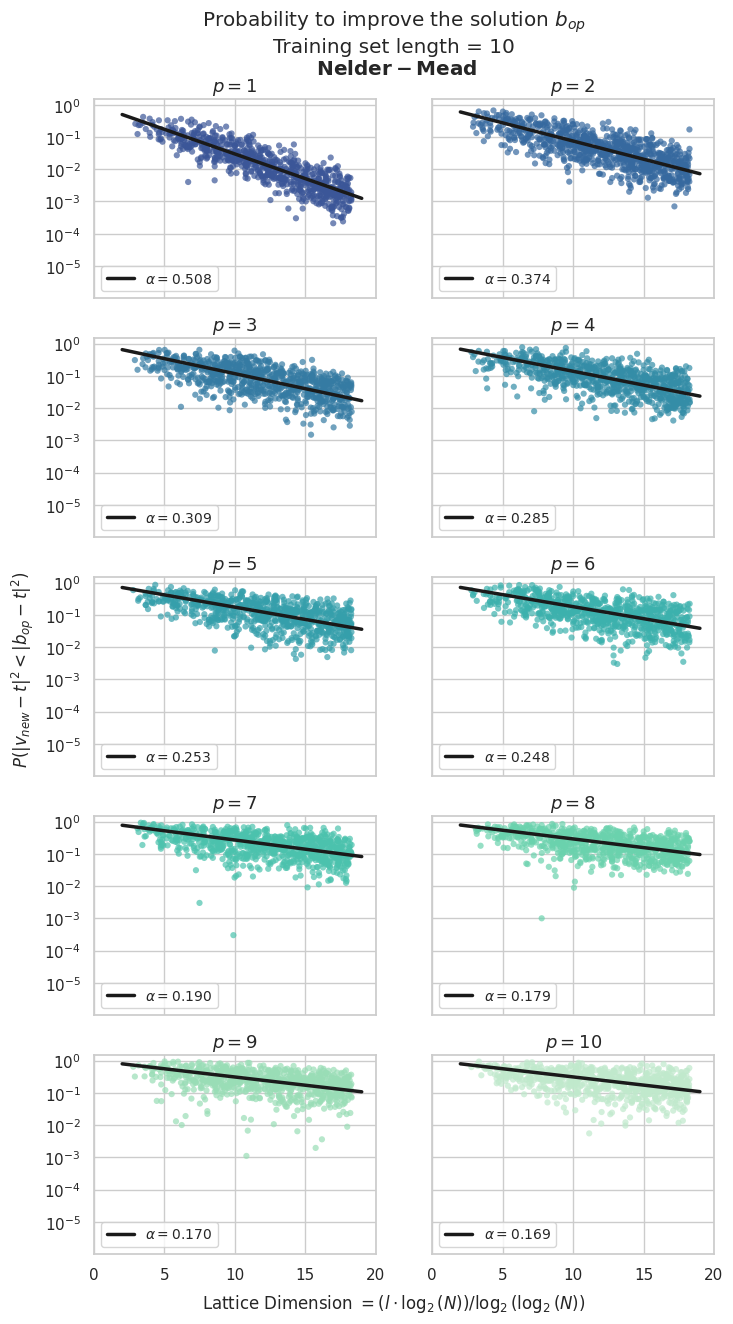

In [85]:
show_data(infile = "./results/scalability_results/datas2400_from9to128_1_NelderMead_p", 
        outfile = "./figures/scalability_datas2400_from9to128_1_NelderMead.png",
        min_method = "Nelder-Mead", training_set_length=10)

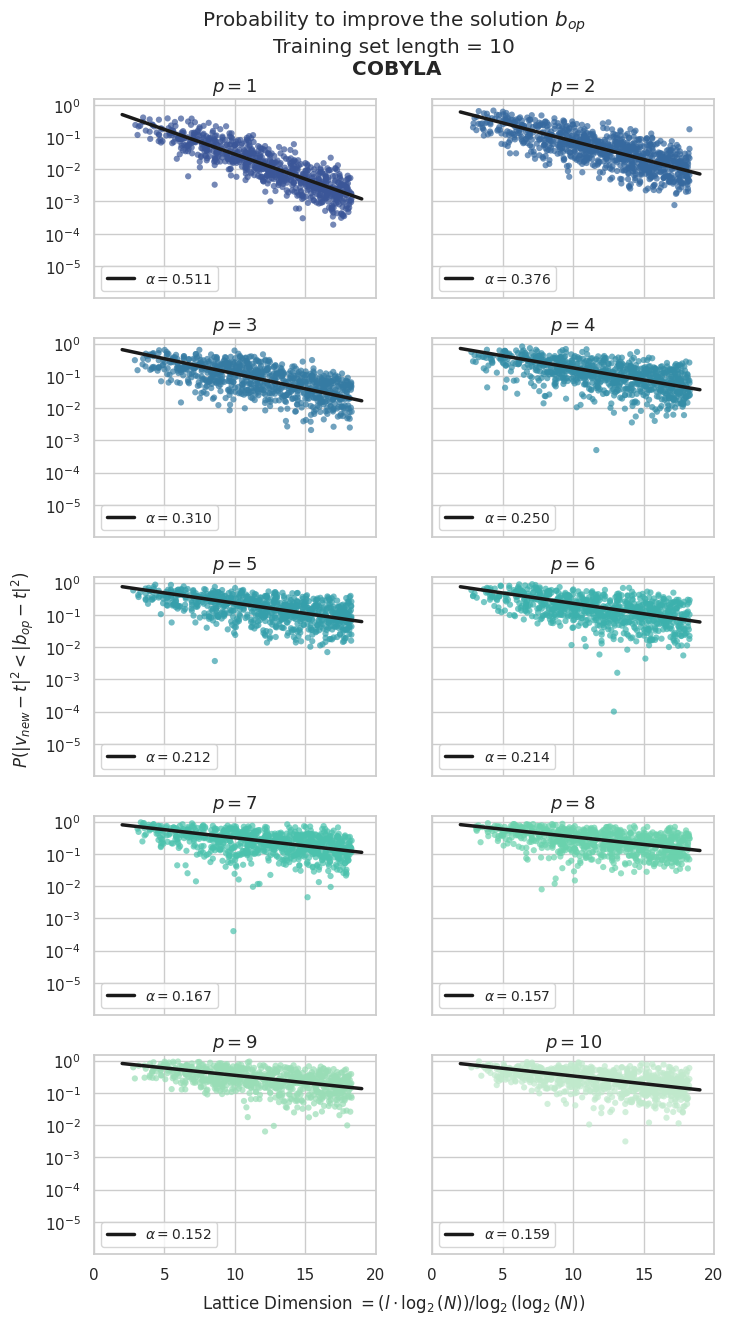

In [86]:
show_data(infile = "./results/scalability_results/datas2400_from9to128_1_COBYLA_p", 
        outfile = "./figures/scalability_datas2400_from9to128_1_COBYLA.png",
        min_method = "COBYLA", training_set_length=10)

### Conjunto de datos de 4200 elementos

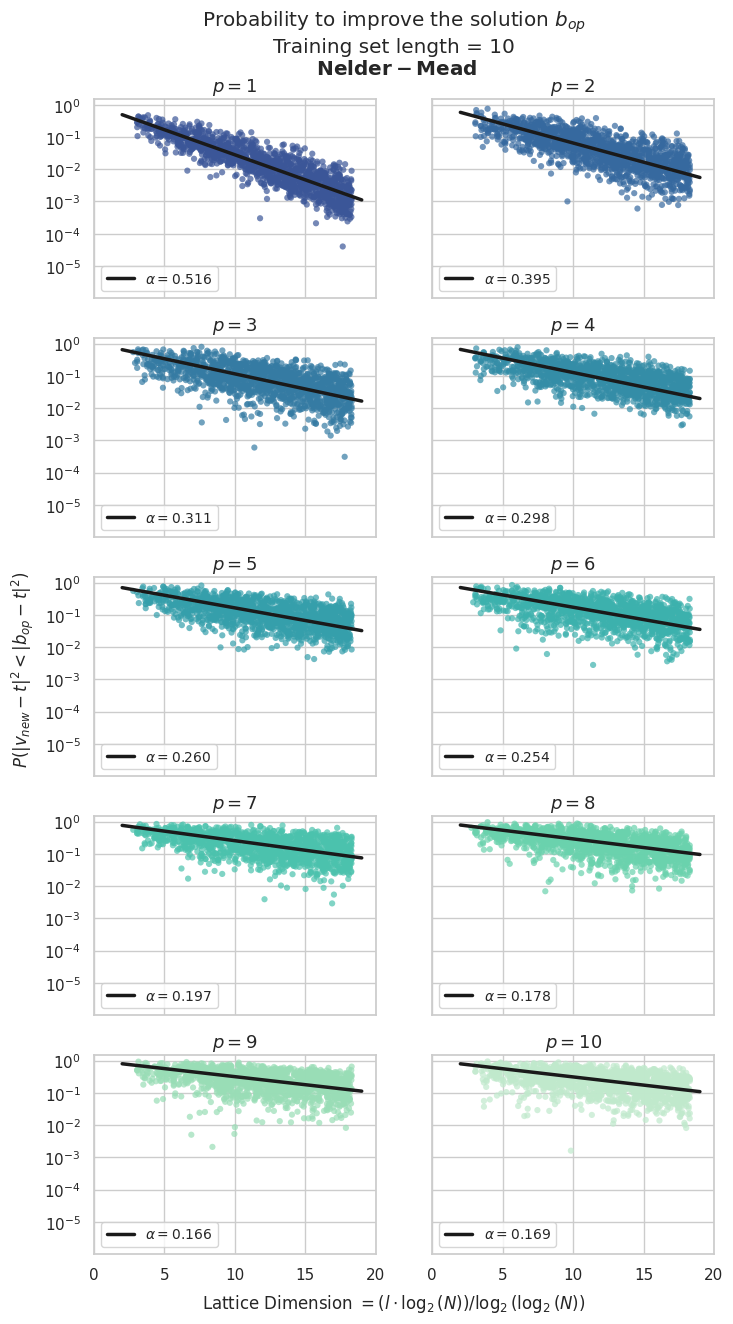

In [87]:
show_data(infile = "./results/scalability_results/datas4200_from9to128_1_NelderMead_p", 
        outfile = "./figures/scalability_datas4200_from9to128_1_NelderMead.png",
        min_method = "Nelder-Mead", training_set_length=10)

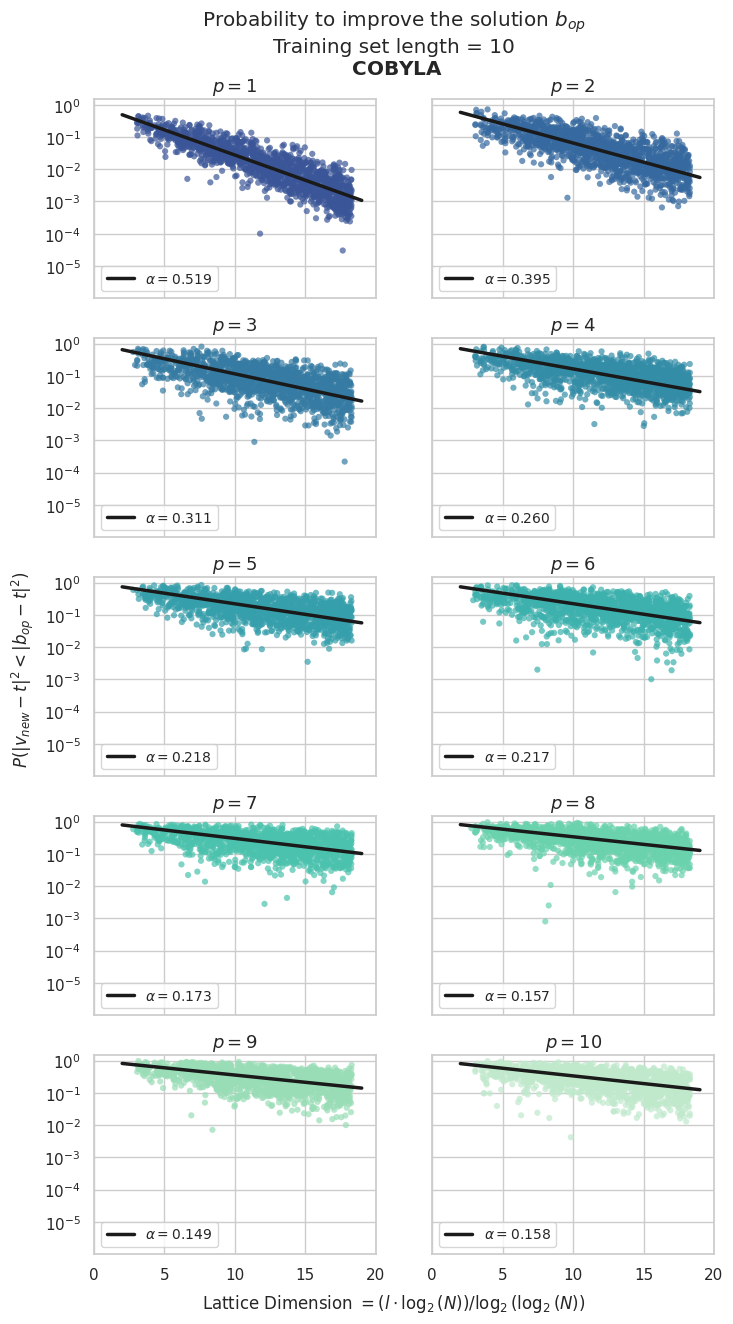

In [88]:
show_data(infile = "./results/scalability_results/datas4200_from9to128_1_COBYLA_p", 
        outfile = "./figures/scalability_datas4200_from9to128_1_COBYLA.png",
        min_method = "COBYLA", training_set_length=10)

## **Entrenamiento 2**

### Conjunto de datos de 1210 elementos

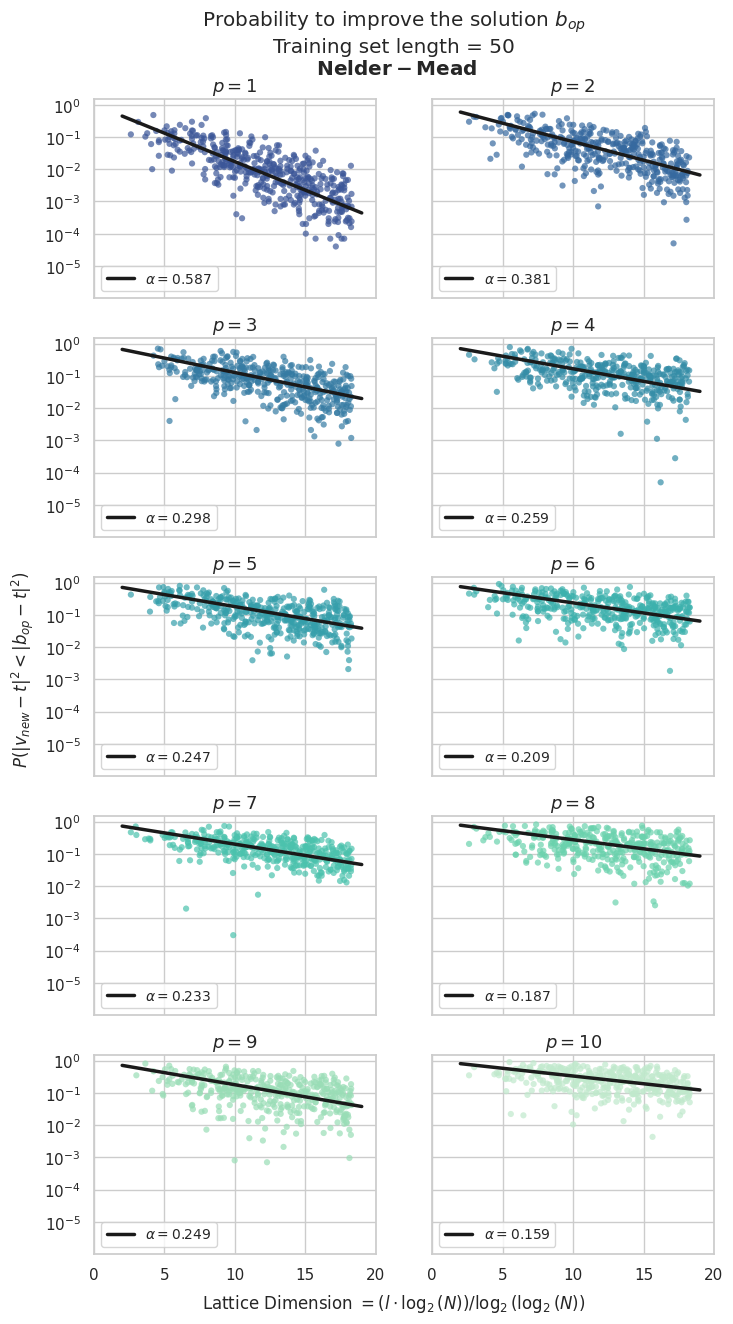

In [89]:
show_data(infile = "./results/scalability_results/datas1210_from8to128_2_NelderMead_p", 
        outfile = "./figures/scalability_datas1210_from8to128_2_NelderMead.png",
        min_method = "Nelder-Mead", training_set_length=50)

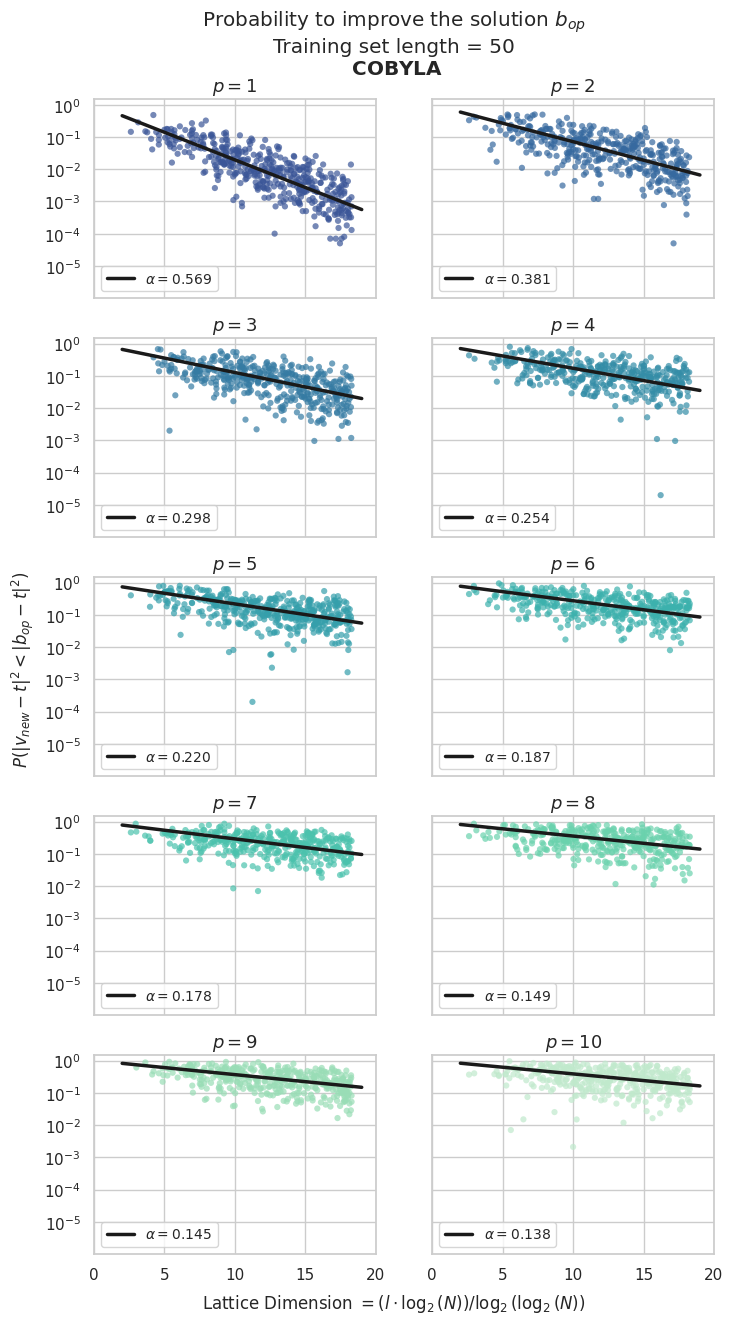

In [90]:
show_data(infile = "./results/scalability_results/datas1210_from8to128_2_COBYLA_p", 
        outfile = "./figures/scalability_datas1210_from8to128_2_COBYLA.png",
        min_method = "COBYLA", training_set_length=50)

### Conjunto de datos de 2400 elementos

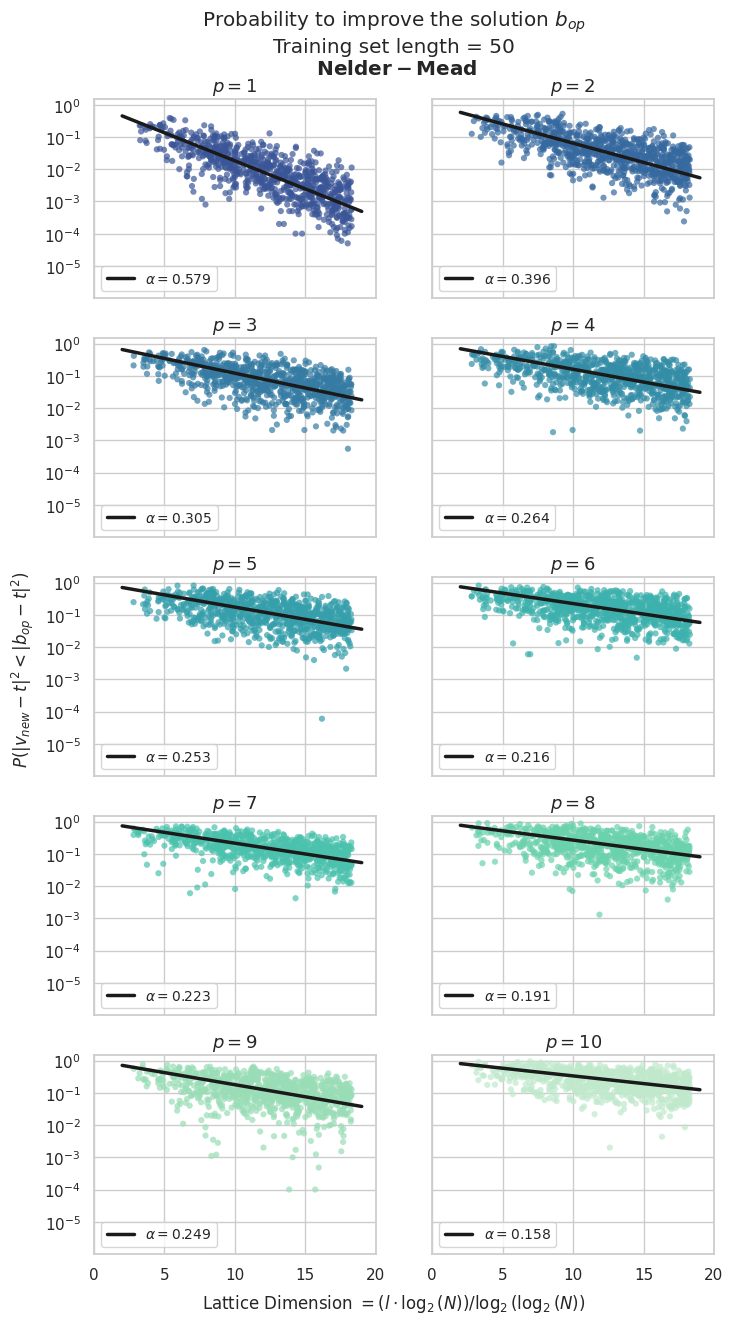

In [91]:
show_data(infile = "./results/scalability_results/datas2400_from9to128_2_NelderMead_p", 
        outfile = "./figures/scalability_datas2400_from9to128_2_NelderMead.png",
        min_method = "Nelder-Mead", training_set_length=50)

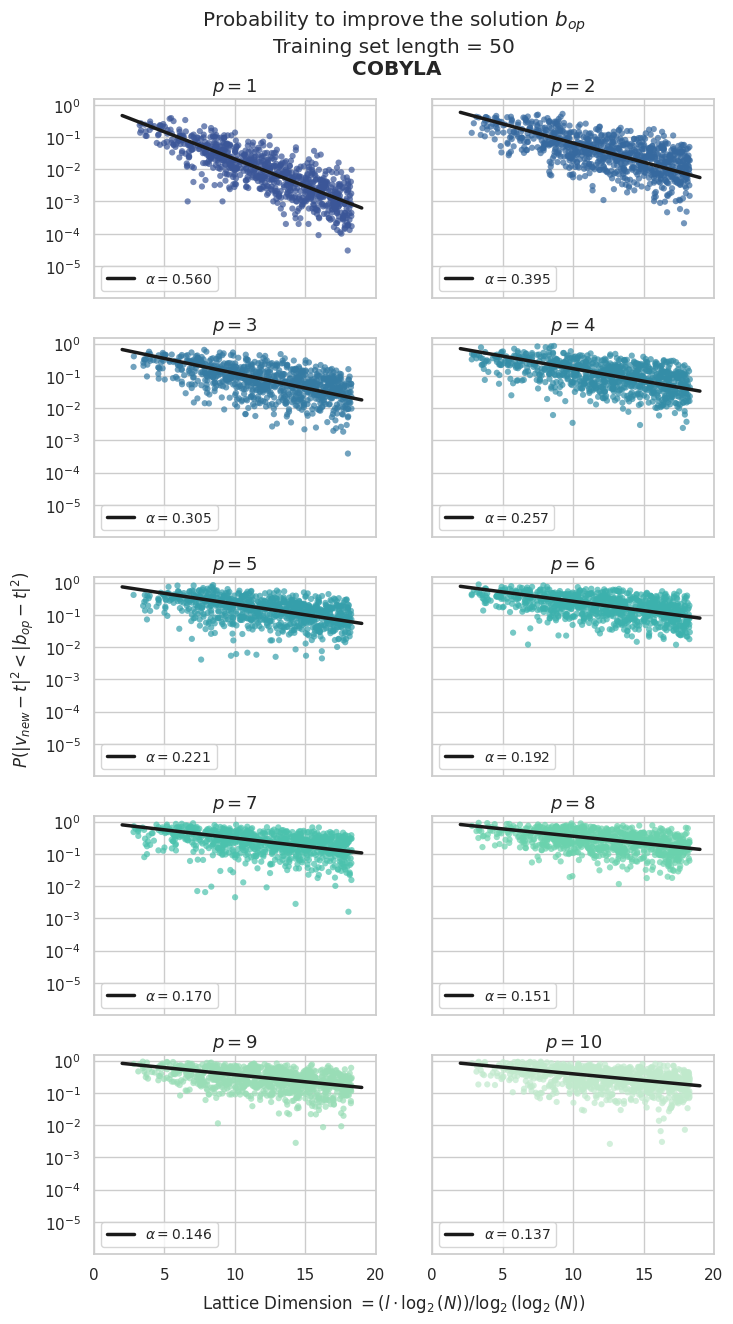

In [92]:
show_data(infile = "./results/scalability_results/datas2400_from9to128_2_COBYLA_p", 
        outfile = "./figures/scalability_datas2400_from9to128_2_COBYLA.png",
        min_method = "COBYLA", training_set_length=50)

### Conjunto de datos de 4200 elementos

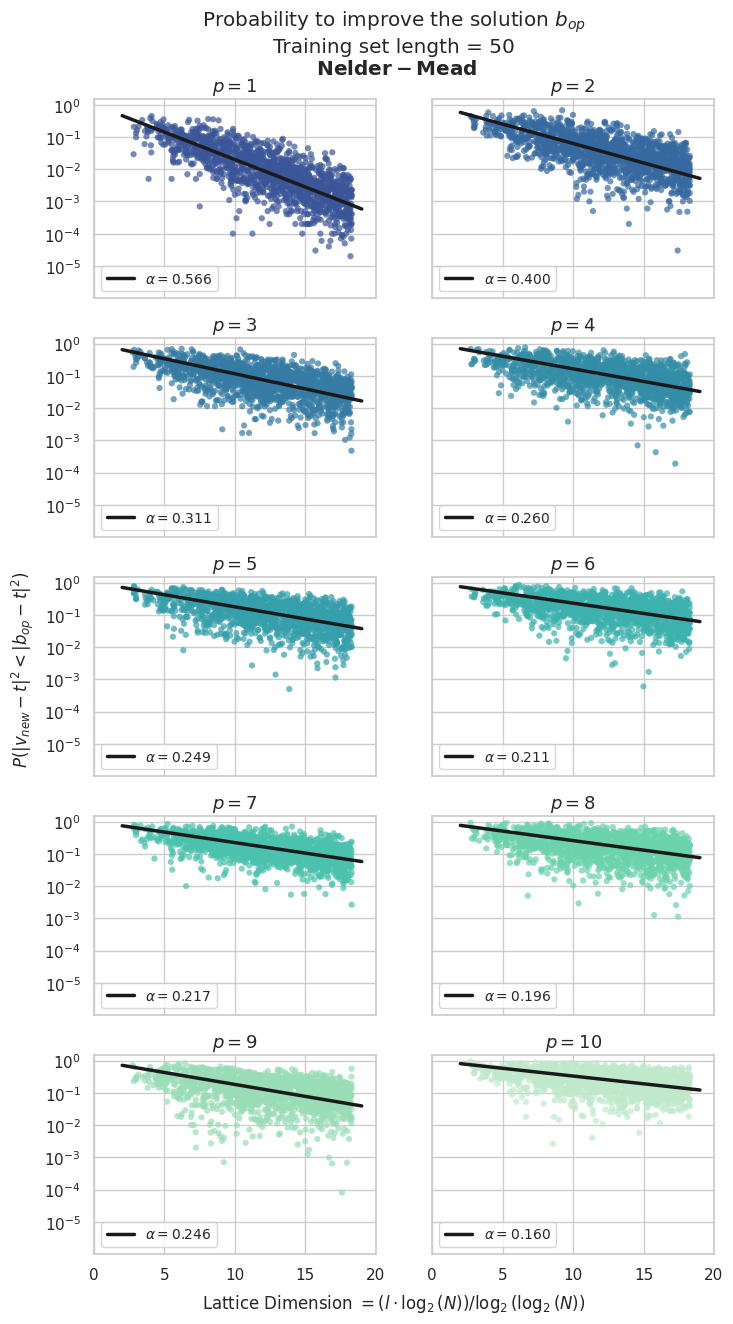

In [93]:
show_data(infile = "./results/scalability_results/datas4200_from9to128_2_NelderMead_p", 
        outfile = "./figures/scalability_datas4200_from9to128_2_NelderMead.png",
        min_method = "Nelder-Mead", training_set_length=50)

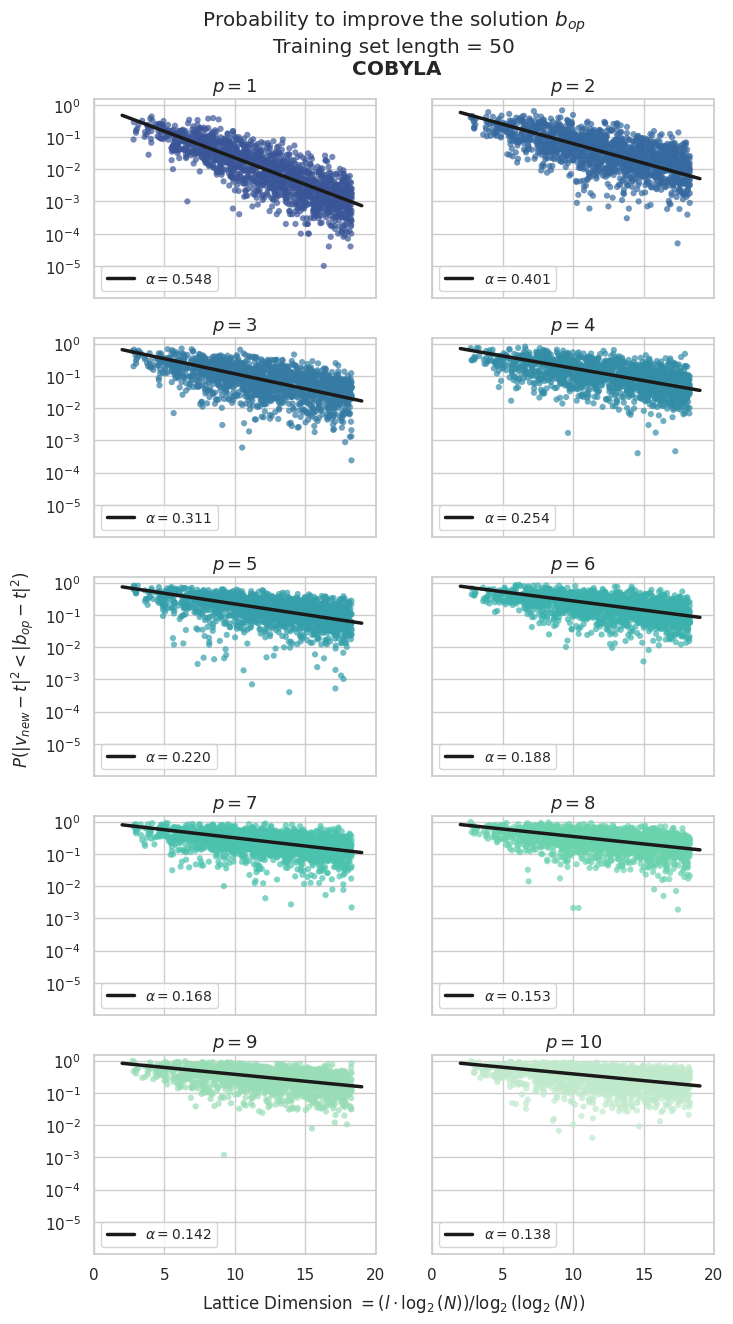

In [94]:
show_data(infile = "./results/scalability_results/datas4200_from9to128_2_COBYLA_p", 
        outfile = "./figures/scalability_datas4200_from9to128_2_COBYLA.png",
        min_method = "COBYLA", training_set_length=50)

## **Comparación de $\alpha$**

In [95]:
sns.set_theme(style="darkgrid", context = "notebook")

In [96]:
def calculate_alphas(infile: str, outfile: str, scal_function):
    alphas = {}
    for p in range(1, 11):
        df = pd.read_csv(f"{infile}{p}.csv")

        positive_probs_df = df[df["P(|vnew - t|^2 < |b_op - t|^2)"] > 0.0]
        log2_N = np.fromiter((math.log2(int(x)) for x in positive_probs_df["N"]),
                            dtype=float, count=len(positive_probs_df))
        dimension_exacta = log2_N / np.log2(log2_N)
        probs = positive_probs_df["P(|vnew - t|^2 < |b_op - t|^2)"].to_numpy()

        alpha = curve_fit(scal_function, xdata = dimension_exacta, ydata=probs)[0][0]

        alphas[p] = alpha

    alphas_df = pd.DataFrame.from_dict(alphas, orient="index", columns=["alpha"])
    alphas_df.index.name = "p"

    alphas_df.to_csv(outfile)

    

In [97]:
# Alphas del primer entrenamiento
calculate_alphas(infile = "./results/scalability_results/datas1210_from8to128_1_NelderMead_p",
                 outfile = "./results/scalability_alphas/alphas_data1210_NelderMead_1.csv",
                 scal_function= scaling_function)
calculate_alphas(infile = "./results/scalability_results/datas1210_from8to128_1_COBYLA_p",
                 outfile = "./results/scalability_alphas/alphas_data1210_COBYLA_1.csv",
                 scal_function= scaling_function)

calculate_alphas(infile = "./results/scalability_results/datas2400_from9to128_1_NelderMead_p",
                 outfile = "./results/scalability_alphas/alphas_data2400_NelderMead_1.csv",
                 scal_function= scaling_function)

calculate_alphas(infile = "./results/scalability_results/datas2400_from9to128_1_COBYLA_p",
                 outfile = "./results/scalability_alphas/alphas_data2400_COBYLA_1.csv",
                 scal_function= scaling_function)

calculate_alphas(infile = "./results/scalability_results/datas4200_from9to128_1_NelderMead_p",
                 outfile = "./results/scalability_alphas/alphas_data4200_NelderMead_1.csv",
                 scal_function= scaling_function)

calculate_alphas(infile = "./results/scalability_results/datas4200_from9to128_1_COBYLA_p",
                 outfile = "./results/scalability_alphas/alphas_data4200_COBYLA_1.csv",
                 scal_function= scaling_function)

In [98]:
#Alphas del segundo entrenamiento
calculate_alphas(infile = "./results/scalability_results/datas1210_from8to128_2_NelderMead_p",
                 outfile = "./results/scalability_alphas/alphas_data1210_NelderMead_2.csv",
                 scal_function= scaling_function)
calculate_alphas(infile = "./results/scalability_results/datas1210_from8to128_2_COBYLA_p",
                 outfile = "./results/scalability_alphas/alphas_data1210_COBYLA_2.csv",
                 scal_function= scaling_function)

calculate_alphas(infile = "./results/scalability_results/datas2400_from9to128_2_NelderMead_p",
                 outfile = "./results/scalability_alphas/alphas_data2400_NelderMead_2.csv",
                 scal_function= scaling_function)

calculate_alphas(infile = "./results/scalability_results/datas2400_from9to128_2_COBYLA_p",
                 outfile = "./results/scalability_alphas/alphas_data2400_COBYLA_2.csv",
                 scal_function= scaling_function)

calculate_alphas(infile = "./results/scalability_results/datas4200_from9to128_2_NelderMead_p",
                 outfile = "./results/scalability_alphas/alphas_data4200_NelderMead_2.csv",
                 scal_function= scaling_function)

calculate_alphas(infile = "./results/scalability_results/datas4200_from9to128_2_COBYLA_p",
                 outfile = "./results/scalability_alphas/alphas_data4200_COBYLA_2.csv",
                 scal_function= scaling_function)

In [99]:
benPriestley_alphas = [0.582, 0.408, 0.447, 0.382, 0.282, 0.445, 0.377, 0.330, 0.231, 0.225]

In [100]:
nrows = 2
ncols = 5

### Entrenamiento 1

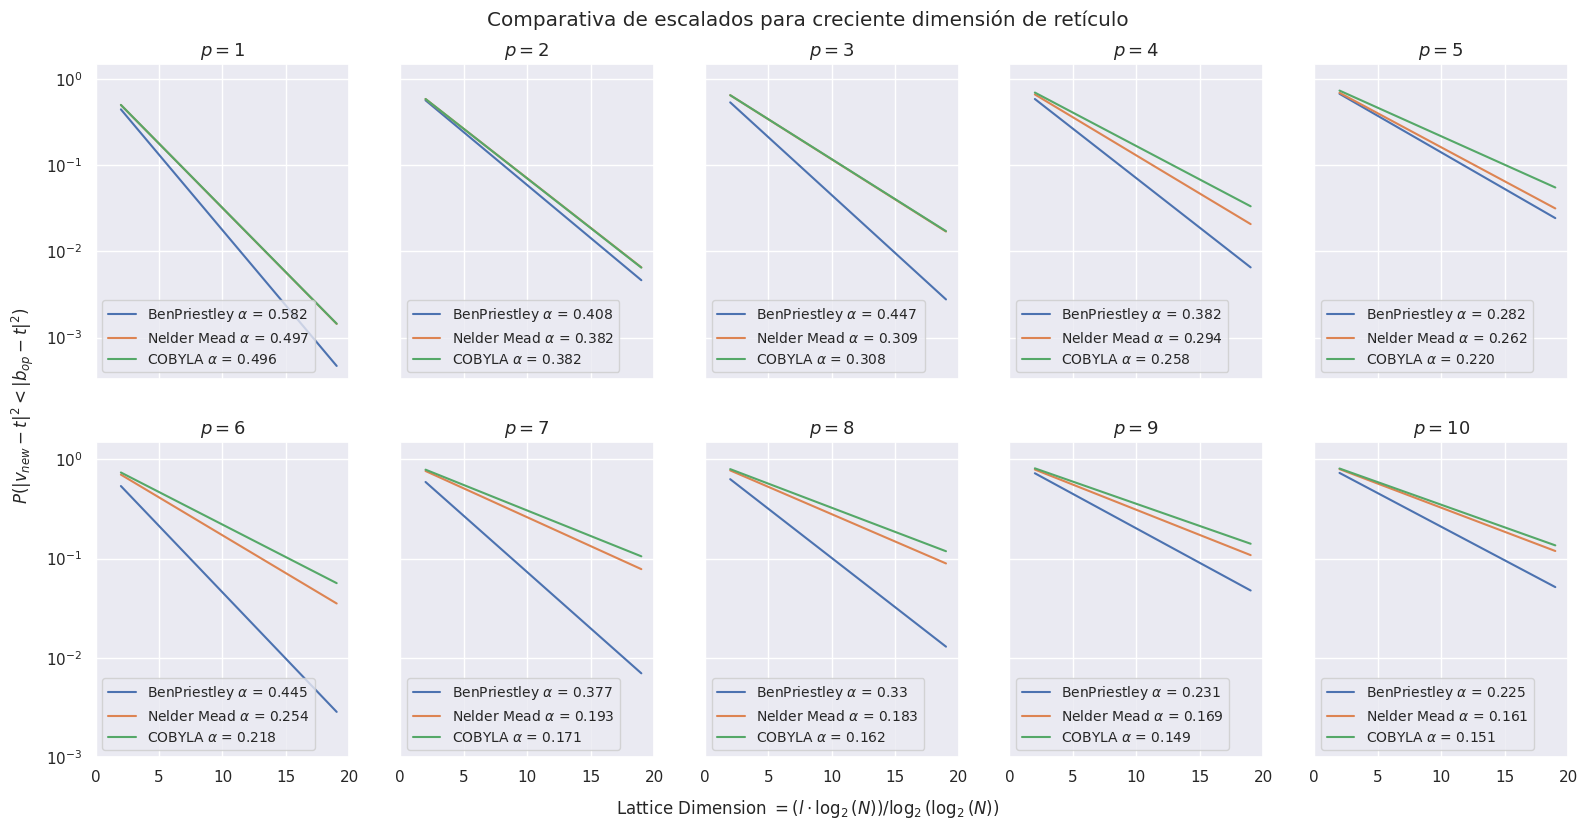

In [101]:
nelder_df = pd.read_csv("./results/scalability_alphas/alphas_data1210_NelderMead_1.csv")
coobyla_df = pd.read_csv("./results/scalability_alphas/alphas_data1210_COBYLA_1.csv")
fig, axes = plt.subplots(nrows = nrows, ncols = ncols, 
                         figsize=(19, 9),
                        sharey = 'row', sharex = 'col' )

axes_flat = axes.flatten()

for p in range(1, 11):
    idx = p - 1
    ax = axes_flat[idx]

    step_size = .1
    xs = np.arange(start=2, stop=19+step_size, step=step_size)


    b_ys = [scaling_function(x, benPriestley_alphas[idx]) for x in xs]
    sns.lineplot(x = xs, y = b_ys, ax = ax, label = f'BenPriestley $\\alpha$ = {benPriestley_alphas[idx]}')

    
    n_alpha = nelder_df["alpha"][idx] 

    
    c_alpha = coobyla_df["alpha"][idx]

    n_ys = [scaling_function(x, n_alpha) for x in xs]
    c_ys = [scaling_function(x, c_alpha) for x in xs]

    sns.lineplot(x = xs, y = n_ys, ax = ax, label = f'Nelder Mead $\\alpha$ = {n_alpha:.3f}')
    sns.lineplot(x = xs, y = c_ys, ax = ax, label = f'COBYLA $\\alpha$ = {c_alpha:.3f}')


    ax.legend(fontsize = 10, loc="lower left")

    ax.set_title(rf"$p = {p}$", fontsize=13, fontweight="bold")
    ax.set_xticks(np.arange(0, 21, 5))

    ax.set_yscale("log")
    ax.set_ylim(0, 1.5)
    ax.set_yticks([10**i for i in range(0, -4, -1)])

fig.suptitle(
    "Comparativa de escalados para creciente dimensión de retículo",
    y=0.94
)

fig.supylabel(
        r'$P(|v_{new} - t|^2 < |b_{op} - t|^2)$',
        fontsize=12,
        x=0.08  # ajusta la distancia horizontal al borde izquierdo
    )
fig.supxlabel(
    r'Lattice Dimension $= (l \cdot \log_2(N))/\log_2(\log_2(N))$',
    fontsize=12,
    y=0.04  
)

fig.savefig("./figures/scalability_alphas_comparison_data1210_1", dpi=300, bbox_inches='tight')

plt.show()


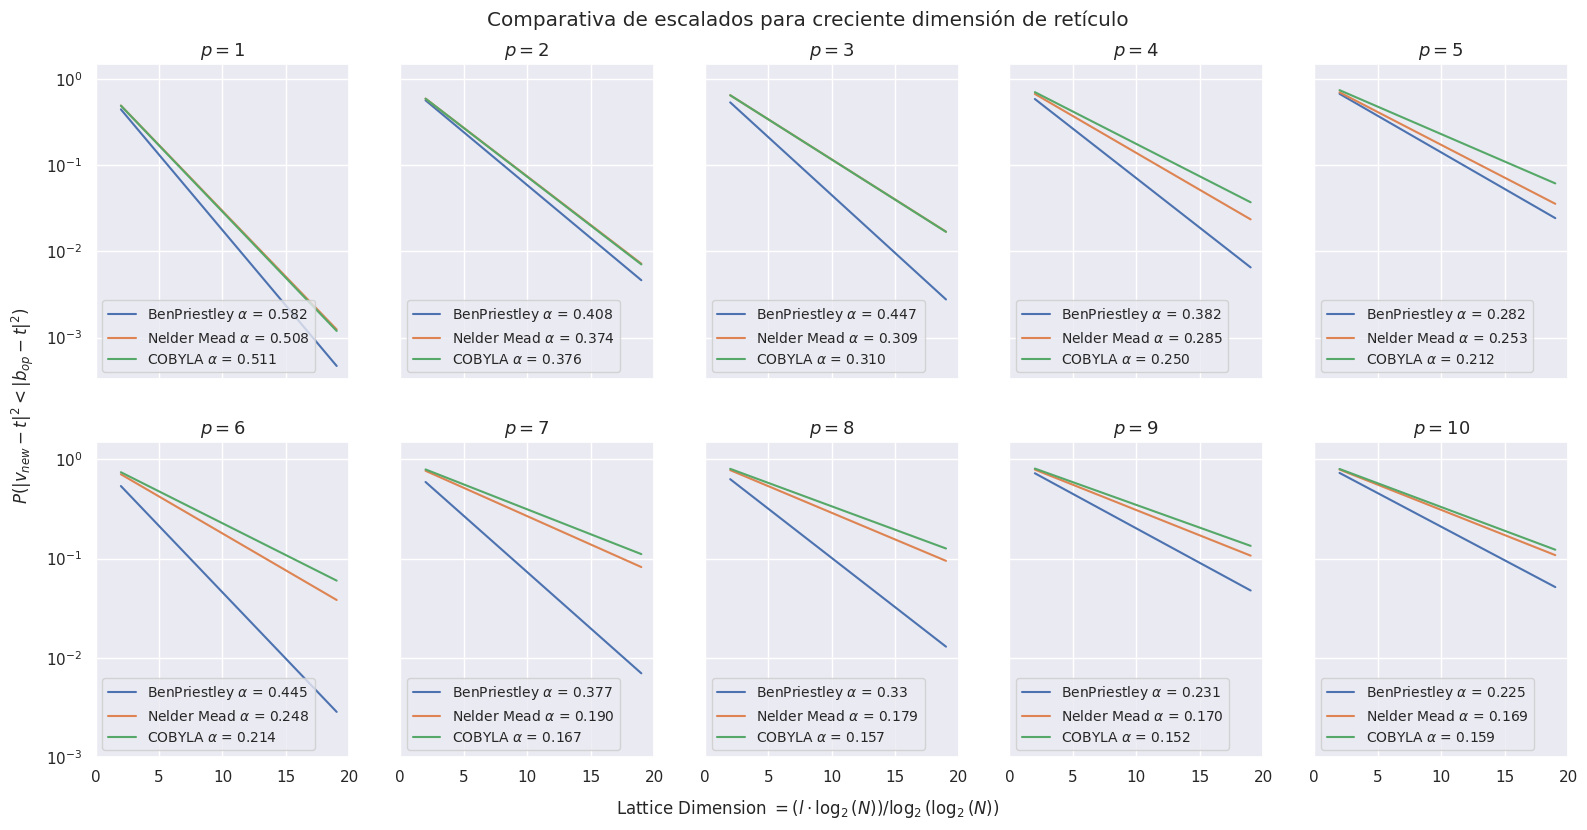

In [102]:
nelder_df = pd.read_csv("./results/scalability_alphas/alphas_data2400_NelderMead_1.csv")
coobyla_df = pd.read_csv("./results/scalability_alphas/alphas_data2400_COBYLA_1.csv")
fig, axes = plt.subplots(nrows = nrows, ncols = ncols, 
                         figsize=(19, 9),
                        sharey = 'row', sharex = 'col' )

axes_flat = axes.flatten()

for p in range(1, 11):
    idx = p - 1
    ax = axes_flat[idx]

    step_size = .1
    xs = np.arange(start=2, stop=19+step_size, step=step_size)


    b_ys = [scaling_function(x, benPriestley_alphas[idx]) for x in xs]
    sns.lineplot(x = xs, y = b_ys, ax = ax, label = f'BenPriestley $\\alpha$ = {benPriestley_alphas[idx]}')

    
    n_alpha = nelder_df["alpha"][idx] 

    
    c_alpha = coobyla_df["alpha"][idx]

    n_ys = [scaling_function(x, n_alpha) for x in xs]
    c_ys = [scaling_function(x, c_alpha) for x in xs]

    sns.lineplot(x = xs, y = n_ys, ax = ax, label = f'Nelder Mead $\\alpha$ = {n_alpha:.3f}')
    sns.lineplot(x = xs, y = c_ys, ax = ax, label = f'COBYLA $\\alpha$ = {c_alpha:.3f}')


    ax.legend(fontsize = 10, loc="lower left")

    ax.set_title(rf"$p = {p}$", fontsize=13, fontweight="bold")
    ax.set_xticks(np.arange(0, 21, 5))

    ax.set_yscale("log")
    ax.set_ylim(0, 1.5)
    ax.set_yticks([10**i for i in range(0, -4, -1)])

fig.suptitle(
    "Comparativa de escalados para creciente dimensión de retículo",
    y=0.94
)

fig.supylabel(
        r'$P(|v_{new} - t|^2 < |b_{op} - t|^2)$',
        fontsize=12,
        x=0.08  # ajusta la distancia horizontal al borde izquierdo
    )
fig.supxlabel(
    r'Lattice Dimension $= (l \cdot \log_2(N))/\log_2(\log_2(N))$',
    fontsize=12,
    y=0.04  
)

fig.savefig("./figures/scalability_alphas_comparison_data2400_1", dpi=300, bbox_inches='tight')

plt.show()


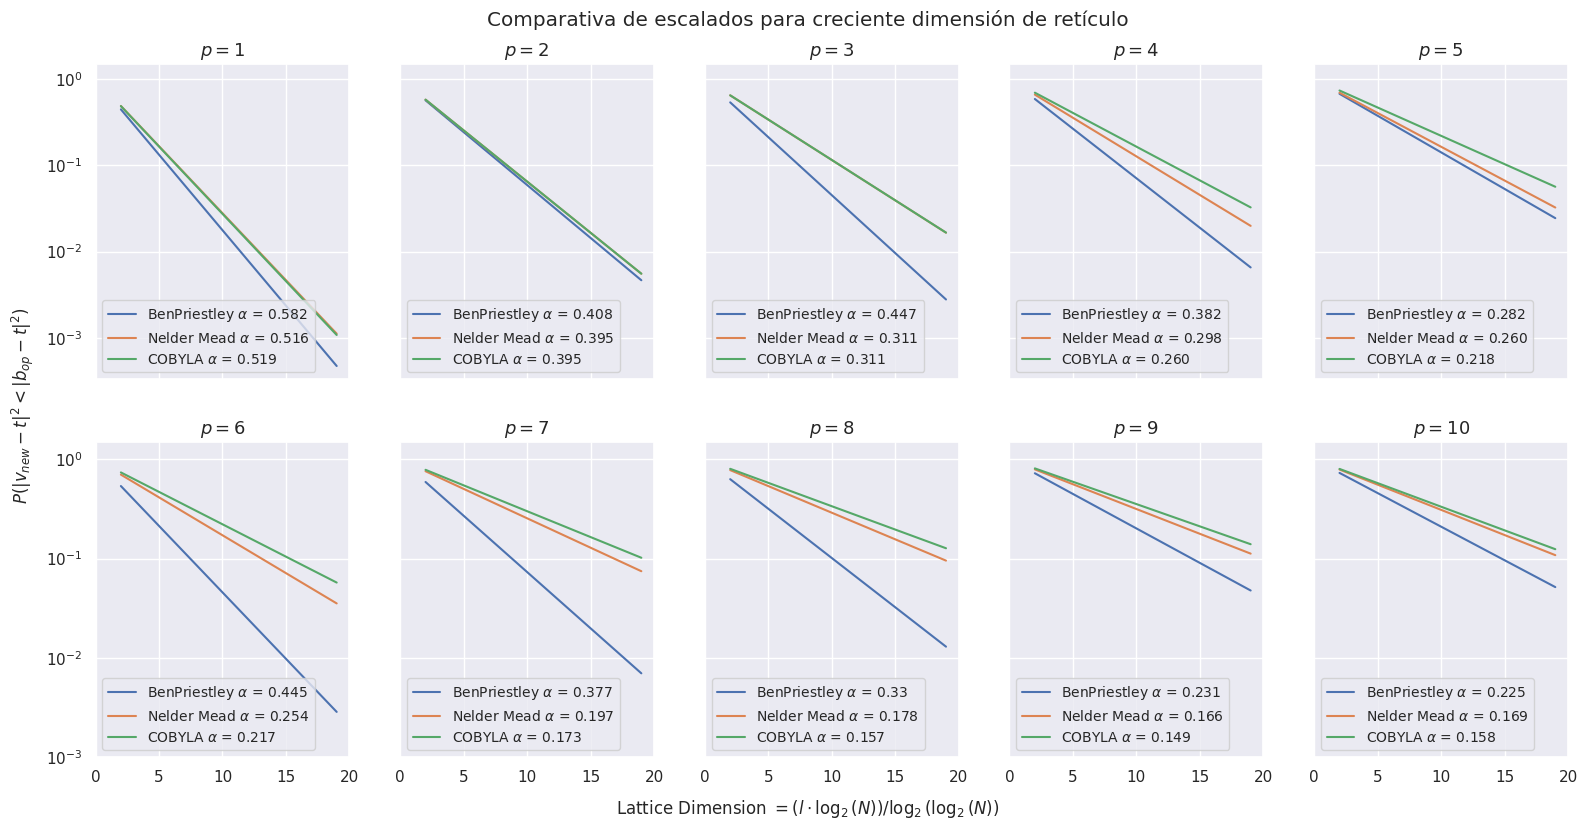

In [103]:
nelder_df = pd.read_csv("./results/scalability_alphas/alphas_data4200_NelderMead_1.csv")
coobyla_df = pd.read_csv("./results/scalability_alphas/alphas_data4200_COBYLA_1.csv")
fig, axes = plt.subplots(nrows = nrows, ncols = ncols, 
                         figsize=(19, 9),
                        sharey = 'row', sharex = 'col' )

axes_flat = axes.flatten()

for p in range(1, 11):
    idx = p - 1
    ax = axes_flat[idx]

    step_size = .1
    xs = np.arange(start=2, stop=19+step_size, step=step_size)


    b_ys = [scaling_function(x, benPriestley_alphas[idx]) for x in xs]
    sns.lineplot(x = xs, y = b_ys, ax = ax, label = f'BenPriestley $\\alpha$ = {benPriestley_alphas[idx]}')

    
    n_alpha = nelder_df["alpha"][idx] 

    
    c_alpha = coobyla_df["alpha"][idx]

    n_ys = [scaling_function(x, n_alpha) for x in xs]
    c_ys = [scaling_function(x, c_alpha) for x in xs]

    sns.lineplot(x = xs, y = n_ys, ax = ax, label = f'Nelder Mead $\\alpha$ = {n_alpha:.3f}')
    sns.lineplot(x = xs, y = c_ys, ax = ax, label = f'COBYLA $\\alpha$ = {c_alpha:.3f}')


    ax.legend(fontsize = 10, loc="lower left")

    ax.set_title(rf"$p = {p}$", fontsize=13, fontweight="bold")
    ax.set_xticks(np.arange(0, 21, 5))

    ax.set_yscale("log")
    ax.set_ylim(0, 1.5)
    ax.set_yticks([10**i for i in range(0, -4, -1)])

fig.suptitle(
    "Comparativa de escalados para creciente dimensión de retículo",
    y=0.94
)

fig.supylabel(
        r'$P(|v_{new} - t|^2 < |b_{op} - t|^2)$',
        fontsize=12,
        x=0.08  # ajusta la distancia horizontal al borde izquierdo
    )
fig.supxlabel(
    r'Lattice Dimension $= (l \cdot \log_2(N))/\log_2(\log_2(N))$',
    fontsize=12,
    y=0.04  
)

fig.savefig("./figures/scalability_alphas_comparison_data4200_1", dpi=300, bbox_inches='tight')

plt.show()


### Entrenamiento 2

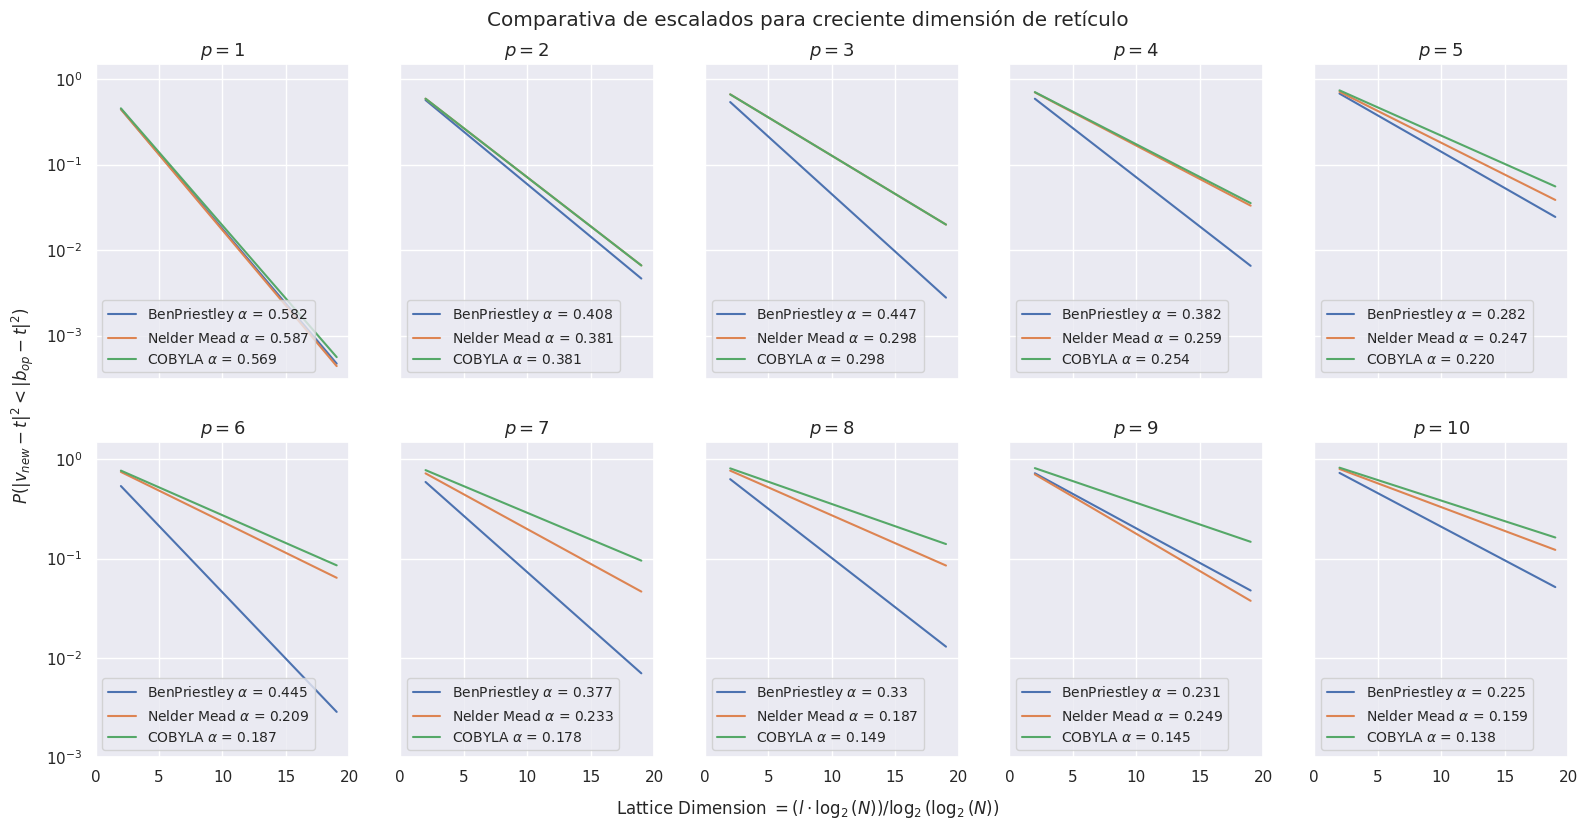

In [104]:
nelder_df = pd.read_csv("./results/scalability_alphas/alphas_data1210_NelderMead_2.csv")
coobyla_df = pd.read_csv("./results/scalability_alphas/alphas_data1210_COBYLA_2.csv")
fig, axes = plt.subplots(nrows = nrows, ncols = ncols, 
                         figsize=(19, 9),
                        sharey = 'row', sharex = 'col' )

axes_flat = axes.flatten()

for p in range(1, 11):
    idx = p - 1
    ax = axes_flat[idx]

    step_size = .1
    xs = np.arange(start=2, stop=19+step_size, step=step_size)


    b_ys = [scaling_function(x, benPriestley_alphas[idx]) for x in xs]
    sns.lineplot(x = xs, y = b_ys, ax = ax, label = f'BenPriestley $\\alpha$ = {benPriestley_alphas[idx]}')

    
    n_alpha = nelder_df["alpha"][idx] 

    
    c_alpha = coobyla_df["alpha"][idx]

    n_ys = [scaling_function(x, n_alpha) for x in xs]
    c_ys = [scaling_function(x, c_alpha) for x in xs]

    sns.lineplot(x = xs, y = n_ys, ax = ax, label = f'Nelder Mead $\\alpha$ = {n_alpha:.3f}')
    sns.lineplot(x = xs, y = c_ys, ax = ax, label = f'COBYLA $\\alpha$ = {c_alpha:.3f}')


    ax.legend(fontsize = 10, loc="lower left")

    ax.set_title(rf"$p = {p}$", fontsize=13, fontweight="bold")
    ax.set_xticks(np.arange(0, 21, 5))

    ax.set_yscale("log")
    ax.set_ylim(0, 1.5)
    ax.set_yticks([10**i for i in range(0, -4, -1)])

fig.suptitle(
    "Comparativa de escalados para creciente dimensión de retículo",
    y=0.94
)

fig.supylabel(
        r'$P(|v_{new} - t|^2 < |b_{op} - t|^2)$',
        fontsize=12,
        x=0.08  # ajusta la distancia horizontal al borde izquierdo
    )
fig.supxlabel(
    r'Lattice Dimension $= (l \cdot \log_2(N))/\log_2(\log_2(N))$',
    fontsize=12,
    y=0.04  
)

fig.savefig("./figures/scalability_alphas_comparison_data1210_2", dpi=300, bbox_inches='tight')

plt.show()


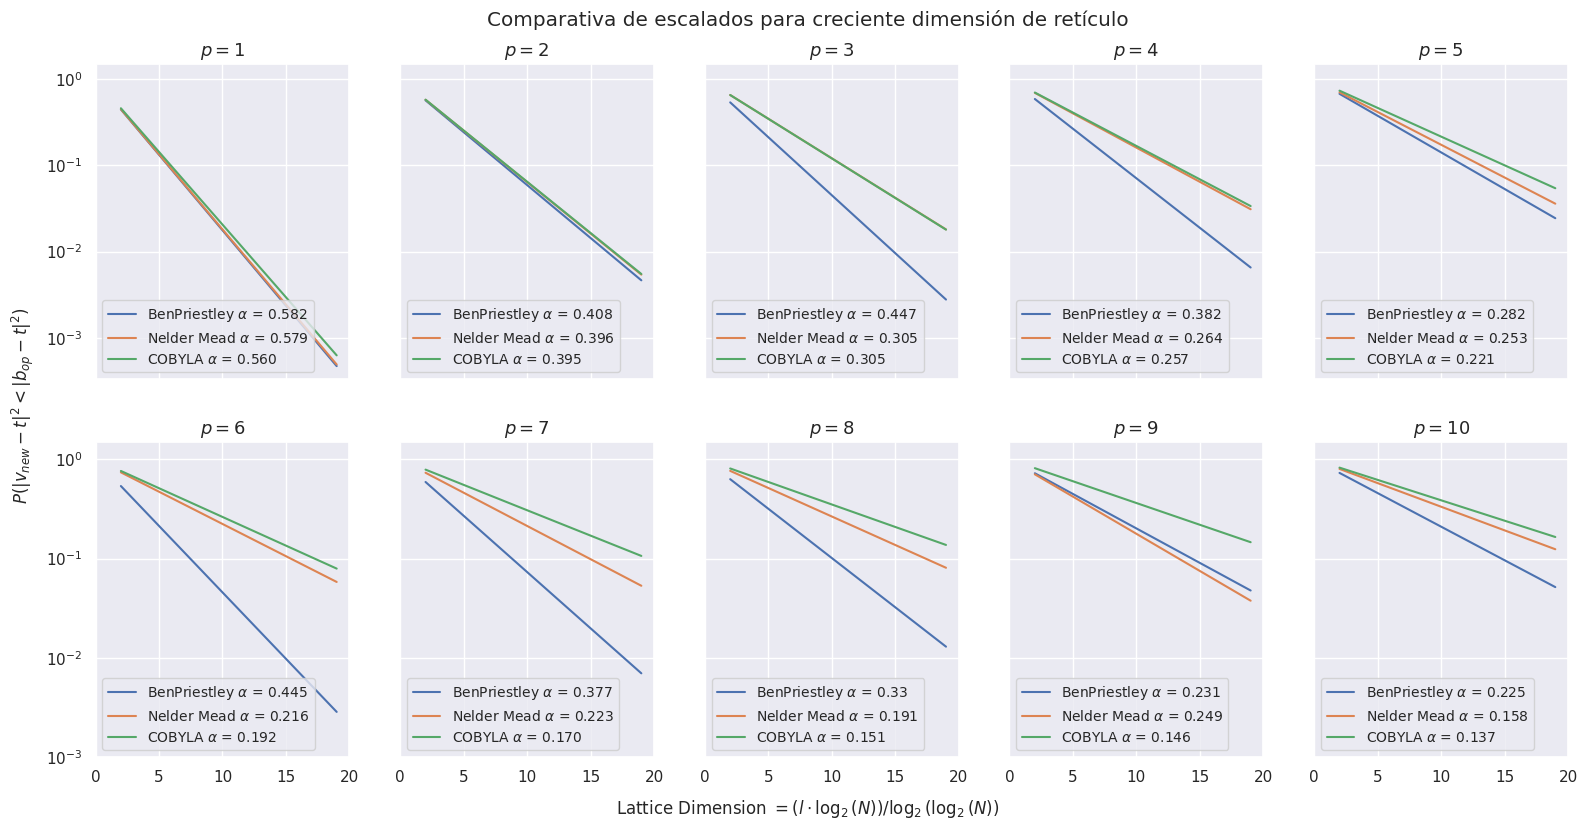

In [105]:
nelder_df = pd.read_csv("./results/scalability_alphas/alphas_data2400_NelderMead_2.csv")
coobyla_df = pd.read_csv("./results/scalability_alphas/alphas_data2400_COBYLA_2.csv")
fig, axes = plt.subplots(nrows = nrows, ncols = ncols, 
                         figsize=(19, 9),
                        sharey = 'row', sharex = 'col' )

axes_flat = axes.flatten()

for p in range(1, 11):
    idx = p - 1
    ax = axes_flat[idx]

    step_size = .1
    xs = np.arange(start=2, stop=19+step_size, step=step_size)


    b_ys = [scaling_function(x, benPriestley_alphas[idx]) for x in xs]
    sns.lineplot(x = xs, y = b_ys, ax = ax, label = f'BenPriestley $\\alpha$ = {benPriestley_alphas[idx]}')

    
    n_alpha = nelder_df["alpha"][idx] 

    
    c_alpha = coobyla_df["alpha"][idx]

    n_ys = [scaling_function(x, n_alpha) for x in xs]
    c_ys = [scaling_function(x, c_alpha) for x in xs]

    sns.lineplot(x = xs, y = n_ys, ax = ax, label = f'Nelder Mead $\\alpha$ = {n_alpha:.3f}')
    sns.lineplot(x = xs, y = c_ys, ax = ax, label = f'COBYLA $\\alpha$ = {c_alpha:.3f}')


    ax.legend(fontsize = 10, loc="lower left")

    ax.set_title(rf"$p = {p}$", fontsize=13, fontweight="bold")
    ax.set_xticks(np.arange(0, 21, 5))

    ax.set_yscale("log")
    ax.set_ylim(0, 1.5)
    ax.set_yticks([10**i for i in range(0, -4, -1)])

fig.suptitle(
    "Comparativa de escalados para creciente dimensión de retículo",
    y=0.94
)

fig.supylabel(
        r'$P(|v_{new} - t|^2 < |b_{op} - t|^2)$',
        fontsize=12,
        x=0.08  # ajusta la distancia horizontal al borde izquierdo
    )
fig.supxlabel(
    r'Lattice Dimension $= (l \cdot \log_2(N))/\log_2(\log_2(N))$',
    fontsize=12,
    y=0.04  
)

fig.savefig("./figures/scalability_alphas_comparison_data2400_2", dpi=300, bbox_inches='tight')

plt.show()


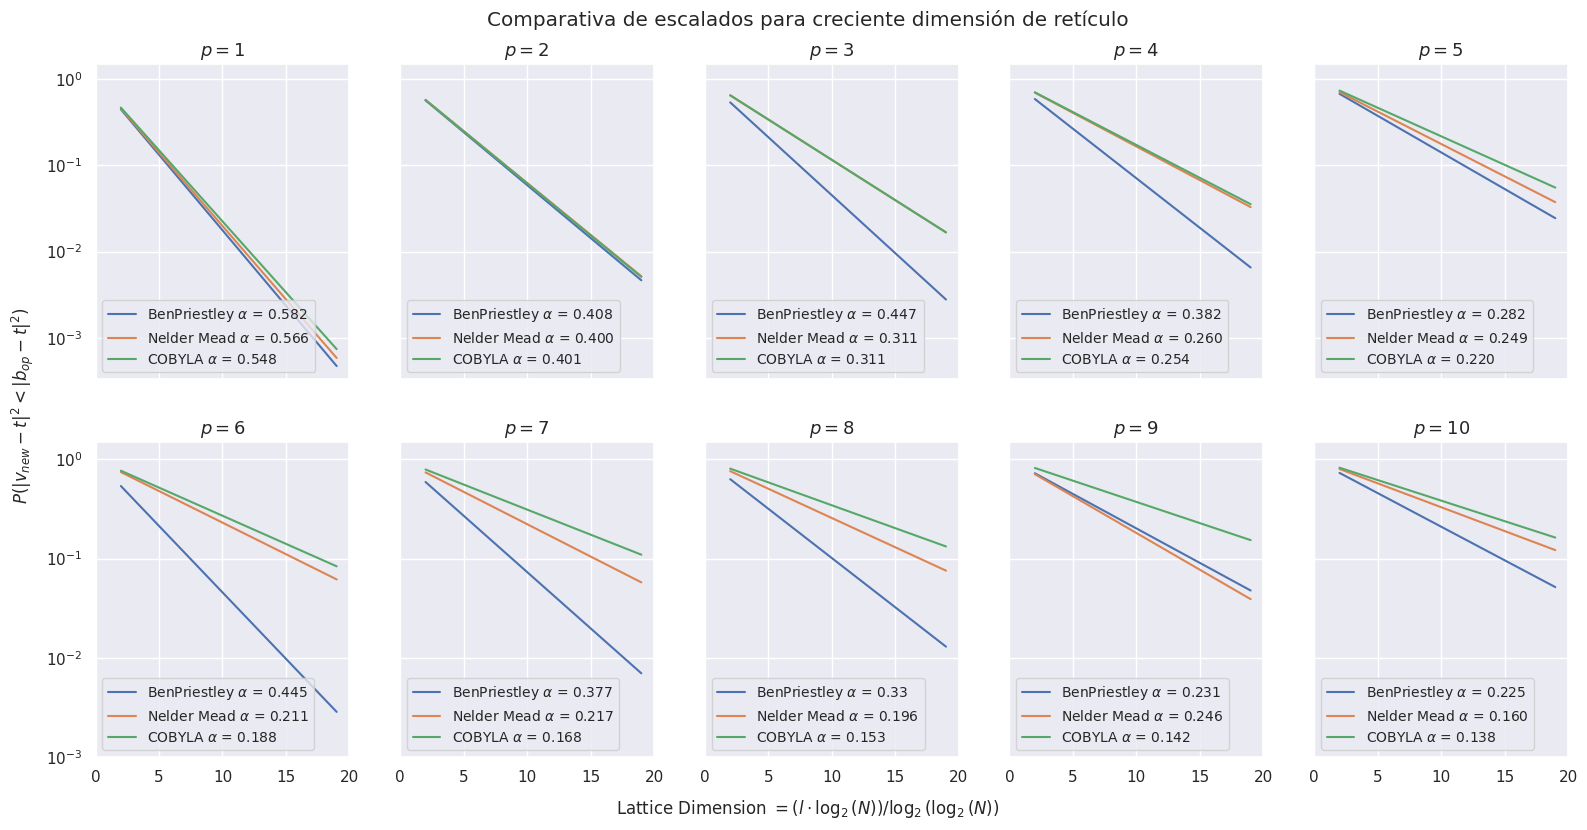

In [106]:
nelder_df = pd.read_csv("./results/scalability_alphas/alphas_data4200_NelderMead_2.csv")
coobyla_df = pd.read_csv("./results/scalability_alphas/alphas_data4200_COBYLA_2.csv")
fig, axes = plt.subplots(nrows = nrows, ncols = ncols, 
                         figsize=(19, 9),
                        sharey = 'row', sharex = 'col' )

axes_flat = axes.flatten()

for p in range(1, 11):
    idx = p - 1
    ax = axes_flat[idx]

    step_size = .1
    xs = np.arange(start=2, stop=19+step_size, step=step_size)


    b_ys = [scaling_function(x, benPriestley_alphas[idx]) for x in xs]
    sns.lineplot(x = xs, y = b_ys, ax = ax, label = f'BenPriestley $\\alpha$ = {benPriestley_alphas[idx]}')

    
    n_alpha = nelder_df["alpha"][idx] 

    
    c_alpha = coobyla_df["alpha"][idx]

    n_ys = [scaling_function(x, n_alpha) for x in xs]
    c_ys = [scaling_function(x, c_alpha) for x in xs]

    sns.lineplot(x = xs, y = n_ys, ax = ax, label = f'Nelder Mead $\\alpha$ = {n_alpha:.3f}')
    sns.lineplot(x = xs, y = c_ys, ax = ax, label = f'COBYLA $\\alpha$ = {c_alpha:.3f}')


    ax.legend(fontsize = 10, loc="lower left")

    ax.set_title(rf"$p = {p}$", fontsize=13, fontweight="bold")
    ax.set_xticks(np.arange(0, 21, 5))

    ax.set_yscale("log")
    ax.set_ylim(0, 1.5)
    ax.set_yticks([10**i for i in range(0, -4, -1)])

fig.suptitle(
    "Comparativa de escalados para creciente dimensión de retículo",
    y=0.94
)

fig.supylabel(
        r'$P(|v_{new} - t|^2 < |b_{op} - t|^2)$',
        fontsize=12,
        x=0.08  # ajusta la distancia horizontal al borde izquierdo
    )
fig.supxlabel(
    r'Lattice Dimension $= (l \cdot \log_2(N))/\log_2(\log_2(N))$',
    fontsize=12,
    y=0.04  
)

fig.savefig("./figures/scalability_alphas_comparison_data4200_2", dpi=300, bbox_inches='tight')

plt.show()


## **Escalabilidad para N's más grandes**

In [107]:
sns.set_theme(style="whitegrid", context = "notebook")

In [108]:
scaling_alphas = pd.read_csv("./results/scalability_alphas/alphas_data4200_COBYLA_2.csv")

#Cargo los alphas de escalado de obtener soluciones que mejoren la obtenida para diferentes p's
print(scaling_alphas)

    p     alpha
0   1  0.547701
1   2  0.401174
2   3  0.310732
3   4  0.253612
4   5  0.219914
5   6  0.188385
6   7  0.167853
7   8  0.153370
8   9  0.142188
9  10  0.137700


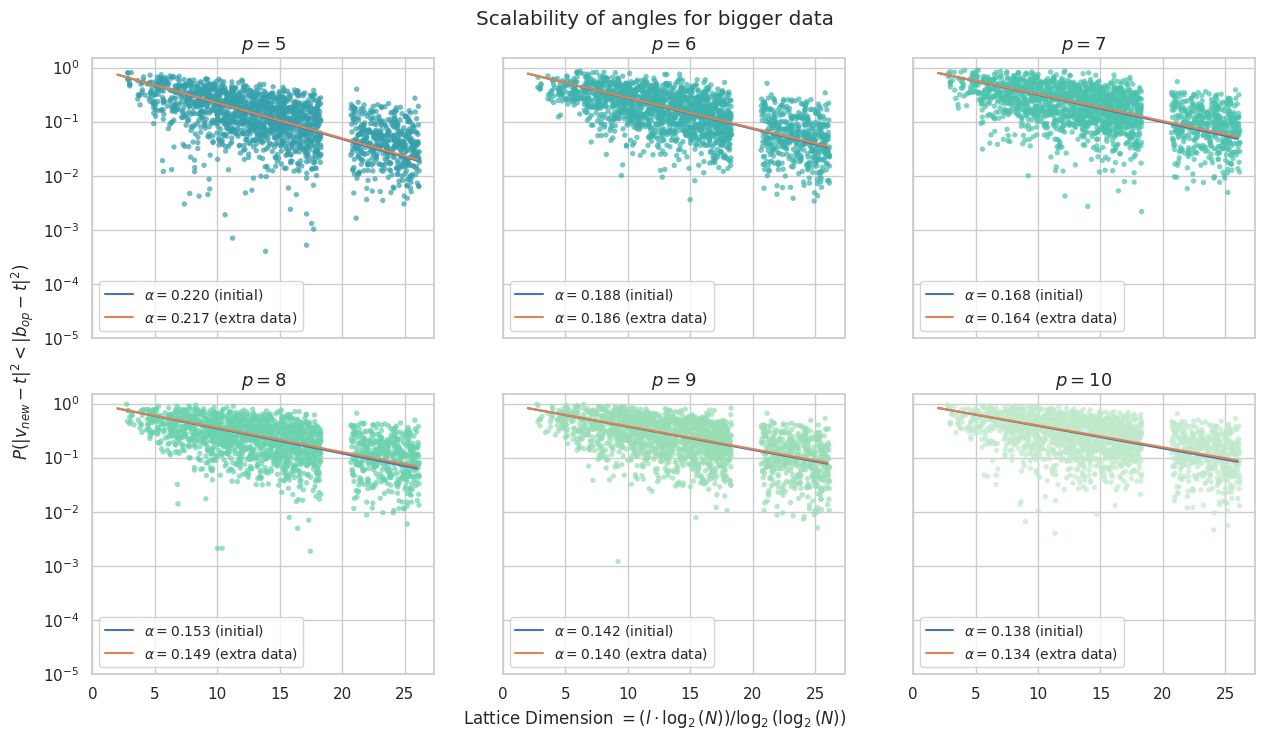

In [109]:
fig, axes = plt.subplots(nrows = 2, ncols = 3, figsize = (15, 8), 
                         sharey = 'row', sharex = 'col')

axes = np.atleast_1d(axes).flatten()

for ax, p in zip(axes, range(5, 11)):
    idx = p - 1
    

    #Cargo los datos de N menores entre 9 y 128 bits
    lower_data_alpha = scaling_alphas["alpha"][idx]
    data_df = pd.read_csv(f"./results/scalability_results/datas4200_from9to128_2_COBYLA_p{p}.csv")
    lower_data_positive = data_df[data_df["P(|vnew - t|^2 < |b_op - t|^2)"] > 0.0]
    lower_data_exact_dimension = np.log2(lower_data_positive["N"].to_numpy())/np.log2(np.log2(lower_data_positive["N"].to_numpy()))
    
    #lower_data_lattice_dimension = lower_data_positive["Lattice_dimension"].to_numpy()
    lower_data_probs = lower_data_positive["P(|vnew - t|^2 < |b_op - t|^2)"].to_numpy()

    

    #Cargo los datos de N entre 150 y 200 bits
    extra_df = pd.read_csv(f"./results/scalability_results/datas1020_from150to200_2_COBYLA_p{p}.csv")
    extra_data_positive = extra_df[extra_df["P(|vnew - t|^2 < |b_op - t|^2)"] > 0.0]



    full_data = pd.concat([lower_data_positive, extra_data_positive], ignore_index=True)
    log2_N = np.fromiter((math.log2(int(x)) for x in full_data["N"]),
                     dtype=float, count=len(full_data))
    full_data_exactLat_dimension = log2_N / np.log2(log2_N)
    full_data_probs = full_data["P(|vnew - t|^2 < |b_op - t|^2)"].to_numpy()

    ax.scatter(
            full_data_exactLat_dimension, full_data_probs,
            color=PALETTE[idx], s=15, zorder=2,
            edgecolor = 'none', alpha = 0.7
        )

    full_data_alpha = curve_fit(scaling_function, xdata = full_data_exactLat_dimension, ydata = full_data_probs)[0][0]

    step_size = .1
    xs = np.arange(start=2, stop=26+step_size, step=step_size)
    
    ys_successful = [scaling_function(x, lower_data_alpha) for x in xs]
    sns.lineplot(x=xs, y=ys_successful, ax=ax, 
                 label=f'$\\alpha ={lower_data_alpha:.3f}$ (initial)', linewidth = 1.5)
    
    ys_full_data = [scaling_function(x, full_data_alpha) for x in xs]
    sns.lineplot(x=xs, y=ys_full_data, ax=ax, 
                 label=f'$\\alpha={full_data_alpha:.3f}$ (extra data)', linewidth = 1.5)
    
    



    ax.legend(fontsize = 10, loc="lower left")
    ax.set_title(rf"$p = {p}$", fontsize=13, fontweight="bold")
    ax.set_xticks(np.arange(0, 30, 5))

    ax.set_yscale("log")
    ax.set_ylim(10**-5, 1.5)
    ax.set_yticks([10**i for i in range(0, -6, -1)])


fig.suptitle(
    "Scalability of angles for bigger data",
    y=0.94
)

fig.supylabel(
        r'$P(|v_{new} - t|^2 < |b_{op} - t|^2)$',
        fontsize=12,
        x=0.07  # ajusta la distancia horizontal al borde izquierdo
    )
fig.supxlabel(
    r'Lattice Dimension $= (l \cdot \log_2(N))/\log_2(\log_2(N))$',
    fontsize=12,
    y=0.04  
)

fig.savefig("./figures/scalability_for_bigger_data.png", dpi=300, bbox_inches='tight')

plt.show()

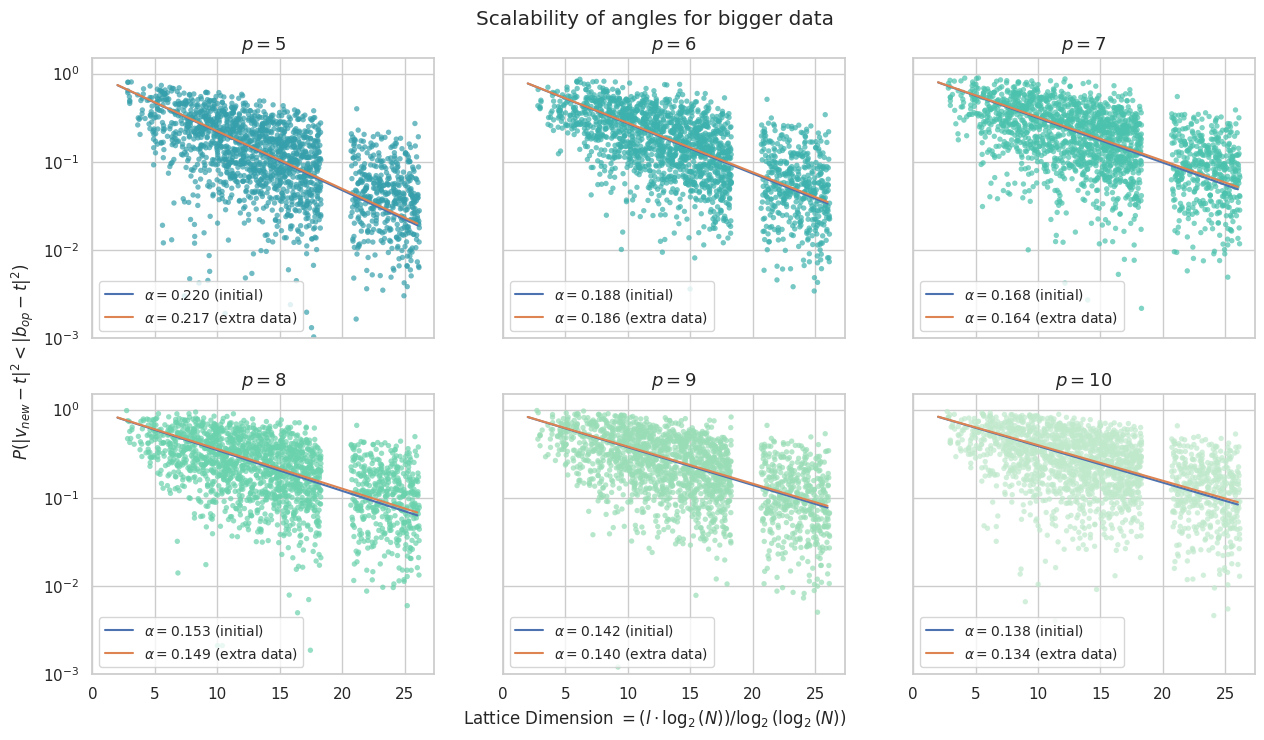

In [110]:
fig, axes = plt.subplots(nrows = 2, ncols = 3, figsize = (15, 8), 
                         sharey = 'row', sharex = 'col')

axes = np.atleast_1d(axes).flatten()

for ax, p in zip(axes, range(5, 11)):
    idx = p - 1
    

    #Cargo los datos de N menores entre 9 y 128 bits
    lower_data_alpha = scaling_alphas["alpha"][idx]
    data_df = pd.read_csv(f"./results/scalability_results/datas4200_from9to128_2_COBYLA_p{p}.csv")
    lower_data_positive = data_df[data_df["P(|vnew - t|^2 < |b_op - t|^2)"] > 0.0]
    lower_data_exact_dimension = np.log2(lower_data_positive["N"].to_numpy())/np.log2(np.log2(lower_data_positive["N"].to_numpy()))
    
    #lower_data_lattice_dimension = lower_data_positive["Lattice_dimension"].to_numpy()
    lower_data_probs = lower_data_positive["P(|vnew - t|^2 < |b_op - t|^2)"].to_numpy()

    

    #Cargo los datos de N entre 150 y 200 bits
    extra_df = pd.read_csv(f"./results/scalability_results/datas1020_from150to200_2_COBYLA_p{p}.csv")
    extra_data_positive = extra_df[extra_df["P(|vnew - t|^2 < |b_op - t|^2)"] > 0.0]



    full_data = pd.concat([lower_data_positive, extra_data_positive], ignore_index=True)
    log2_N = np.fromiter((math.log2(int(x)) for x in full_data["N"]),
                     dtype=float, count=len(full_data))
    full_data_exactLat_dimension = log2_N / np.log2(log2_N)
    full_data_probs = full_data["P(|vnew - t|^2 < |b_op - t|^2)"].to_numpy()

    ax.scatter(
            full_data_exactLat_dimension, full_data_probs,
            color=PALETTE[idx], s=15, zorder=2,
            edgecolor = 'none', alpha = 0.7
        )

    full_data_alpha = curve_fit(scaling_function, xdata = full_data_exactLat_dimension, ydata = full_data_probs)[0][0]

    step_size = .1
    xs = np.arange(start=2, stop=26+step_size, step=step_size)
    
    ys_successful = [scaling_function(x, lower_data_alpha) for x in xs]
    sns.lineplot(x=xs, y=ys_successful, ax=ax, 
                 label=f'$\\alpha ={lower_data_alpha:.3f}$ (initial)', linewidth = 1.5)
    
    ys_full_data = [scaling_function(x, full_data_alpha) for x in xs]
    sns.lineplot(x=xs, y=ys_full_data, ax=ax, 
                 label=f'$\\alpha={full_data_alpha:.3f}$ (extra data)', linewidth = 1.5)
    

    ax.legend(fontsize = 10, loc="lower left")
    ax.set_title(rf"$p = {p}$", fontsize=13, fontweight="bold")
    ax.set_xticks(np.arange(0, 30, 5))

    ax.set_yscale("log")
    ax.set_ylim(10**-3, 1.5)
    ax.set_yticks([10**i for i in range(0, -4, -1)])


fig.suptitle(
    "Scalability of angles for bigger data",
    y=0.94
)

fig.supylabel(
        r'$P(|v_{new} - t|^2 < |b_{op} - t|^2)$',
        fontsize=12,
        x=0.07  # ajusta la distancia horizontal al borde izquierdo
    )
fig.supxlabel(
    r'Lattice Dimension $= (l \cdot \log_2(N))/\log_2(\log_2(N))$',
    fontsize=12,
    y=0.04  
)

fig.savefig("./figures/scalability_for_bigger_data_ampl.png", dpi=300, bbox_inches='tight')

plt.show()

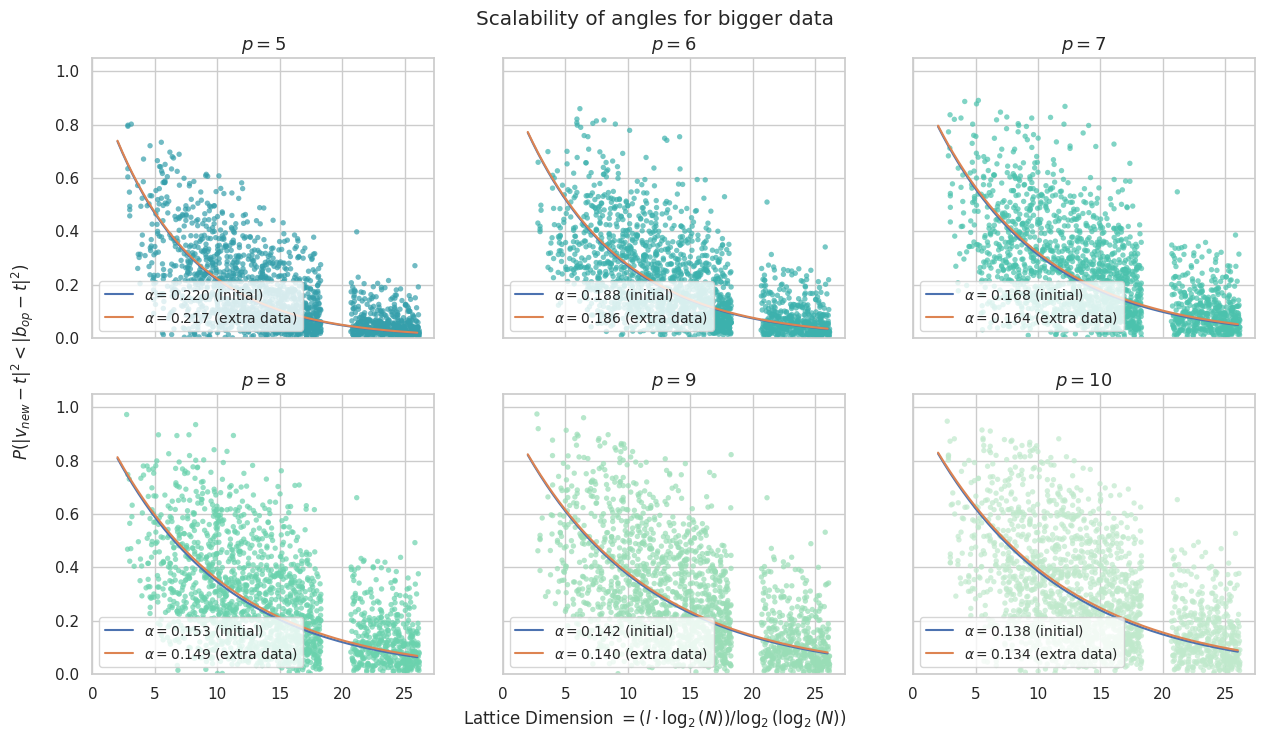

In [111]:
fig, axes = plt.subplots(nrows = 2, ncols = 3, figsize = (15, 8), 
                         sharey = 'row', sharex = 'col')

axes = np.atleast_1d(axes).flatten()

for ax, p in zip(axes, range(5, 11)):
    idx = p - 1
    

    #Cargo los datos de N menores entre 9 y 128 bits
    lower_data_alpha = scaling_alphas["alpha"][idx]
    data_df = pd.read_csv(f"./results/scalability_results/datas4200_from9to128_2_COBYLA_p{p}.csv")
    lower_data_positive = data_df[data_df["P(|vnew - t|^2 < |b_op - t|^2)"] > 0.0]
    lower_data_exact_dimension = np.log2(lower_data_positive["N"].to_numpy())/np.log2(np.log2(lower_data_positive["N"].to_numpy()))
    
    #lower_data_lattice_dimension = lower_data_positive["Lattice_dimension"].to_numpy()
    lower_data_probs = lower_data_positive["P(|vnew - t|^2 < |b_op - t|^2)"].to_numpy()

    

    #Cargo los datos de N entre 150 y 200 bits
    extra_df = pd.read_csv(f"./results/scalability_results/datas1020_from150to200_2_COBYLA_p{p}.csv")
    extra_data_positive = extra_df[extra_df["P(|vnew - t|^2 < |b_op - t|^2)"] > 0.0]



    full_data = pd.concat([lower_data_positive, extra_data_positive], ignore_index=True)
    log2_N = np.fromiter((math.log2(int(x)) for x in full_data["N"]),
                     dtype=float, count=len(full_data))
    full_data_exactLat_dimension = log2_N / np.log2(log2_N)
    full_data_probs = full_data["P(|vnew - t|^2 < |b_op - t|^2)"].to_numpy()

    ax.scatter(
            full_data_exactLat_dimension, full_data_probs,
            color=PALETTE[idx], s=15, zorder=2,
            edgecolor = 'none', alpha = 0.7
        )

    full_data_alpha = curve_fit(scaling_function, xdata = full_data_exactLat_dimension, ydata = full_data_probs)[0][0]

    step_size = .1
    xs = np.arange(start=2, stop=26+step_size, step=step_size)
    
    ys_successful = [scaling_function(x, lower_data_alpha) for x in xs]
    sns.lineplot(x=xs, y=ys_successful, ax=ax, 
                 label=f'$\\alpha ={lower_data_alpha:.3f}$ (initial)', linewidth = 1.5)
    
    ys_full_data = [scaling_function(x, full_data_alpha) for x in xs]
    sns.lineplot(x=xs, y=ys_full_data, ax=ax, 
                 label=f'$\\alpha={full_data_alpha:.3f}$ (extra data)', linewidth = 1.5)
    
    



    ax.legend(fontsize = 10, loc="lower left")
    ax.set_title(rf"$p = {p}$", fontsize=13, fontweight="bold")
    ax.set_xticks(np.arange(0, 30, 5))

    #ax.set_yscale("log")
    ax.set_ylim(0, 1.05)
    ax.set_yticks([i/10 for i in range(0, 11, 2)])


fig.suptitle(
    "Scalability of angles for bigger data",
    y=0.94
)

fig.supylabel(
        r'$P(|v_{new} - t|^2 < |b_{op} - t|^2)$',
        fontsize=12,
        x=0.07  # ajusta la distancia horizontal al borde izquierdo
    )
fig.supxlabel(
    r'Lattice Dimension $= (l \cdot \log_2(N))/\log_2(\log_2(N))$',
    fontsize=12,
    y=0.04  
)

fig.savefig("./figures/scalability_for_bigger_data_normal_scale.png", dpi=300, bbox_inches='tight')

plt.show()

## **Entrenamiento 3**

En esta sección se muestra la escalabilidad de los ángulos encontrados entrenando con un conjunto de 150 y validando con 240, 480 y 960 elementos durante el entreno.

### Caso 240

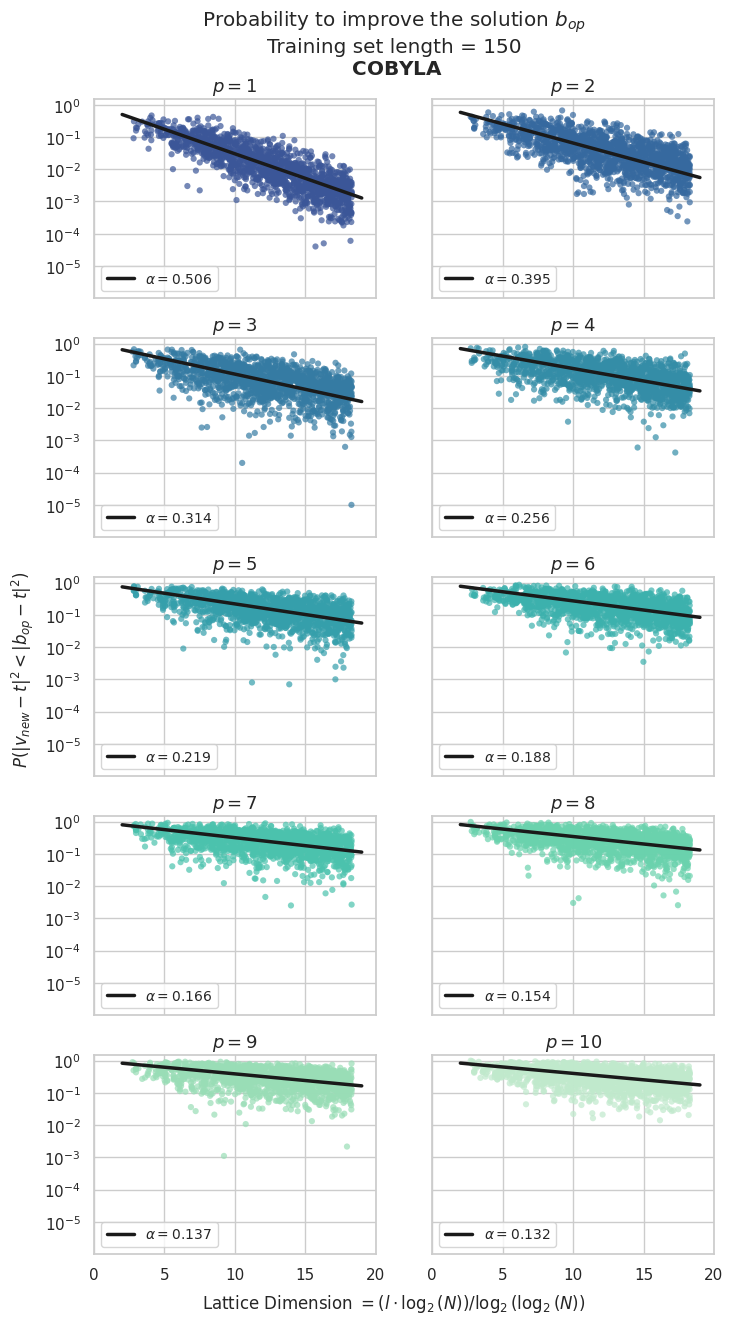

In [112]:
show_data(infile = "./results/scalability_results/datas4200_from9to128_val240_3_COBYLA_p", 
            outfile = "./figures/scalability_datas4200_from9to128_val240_3_COBYLA.png", 
            min_method = "COBYLA", training_set_length=150)

### Caso 480

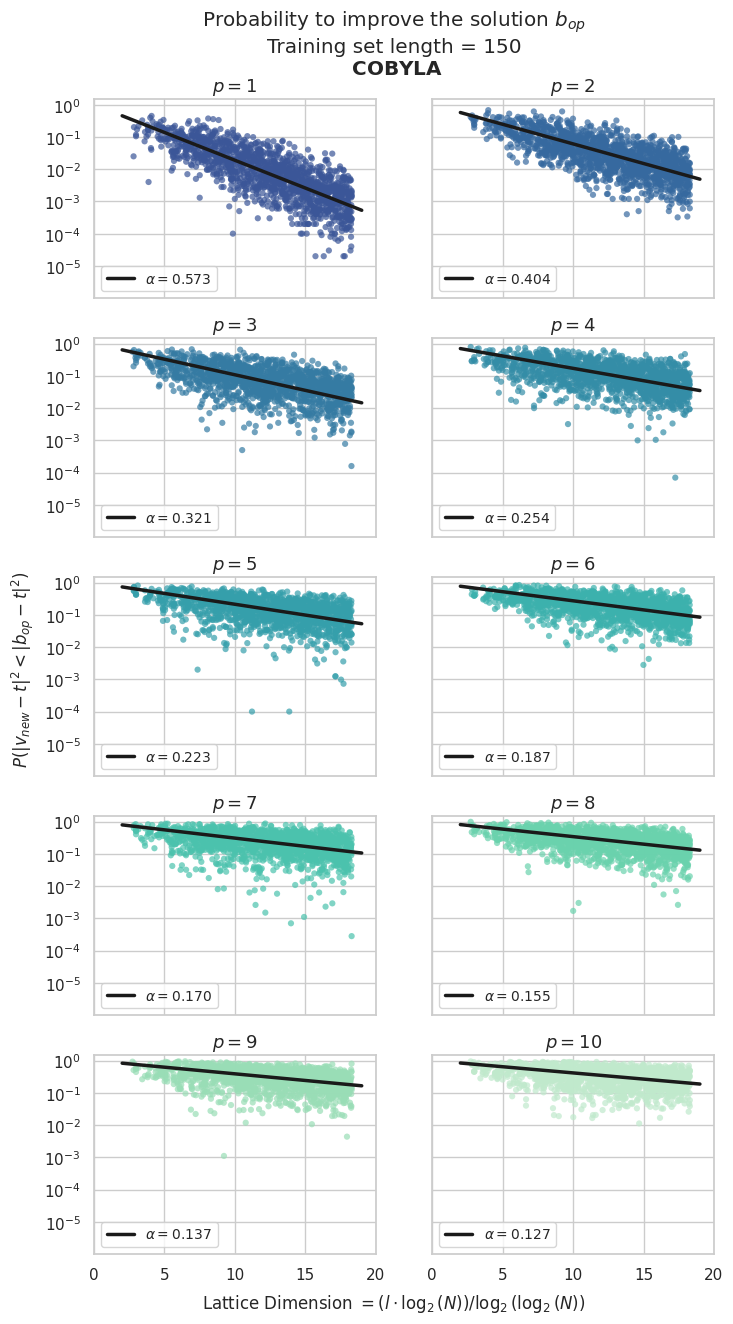

In [113]:
show_data(infile = "./results/scalability_results/datas4200_from9to128_val480_3_COBYLA_p", 
            outfile = "./figures/scalability_datas4200_from9to128_val480_3_COBYLA.png", 
            min_method = "COBYLA", training_set_length=150)

### Caso 960

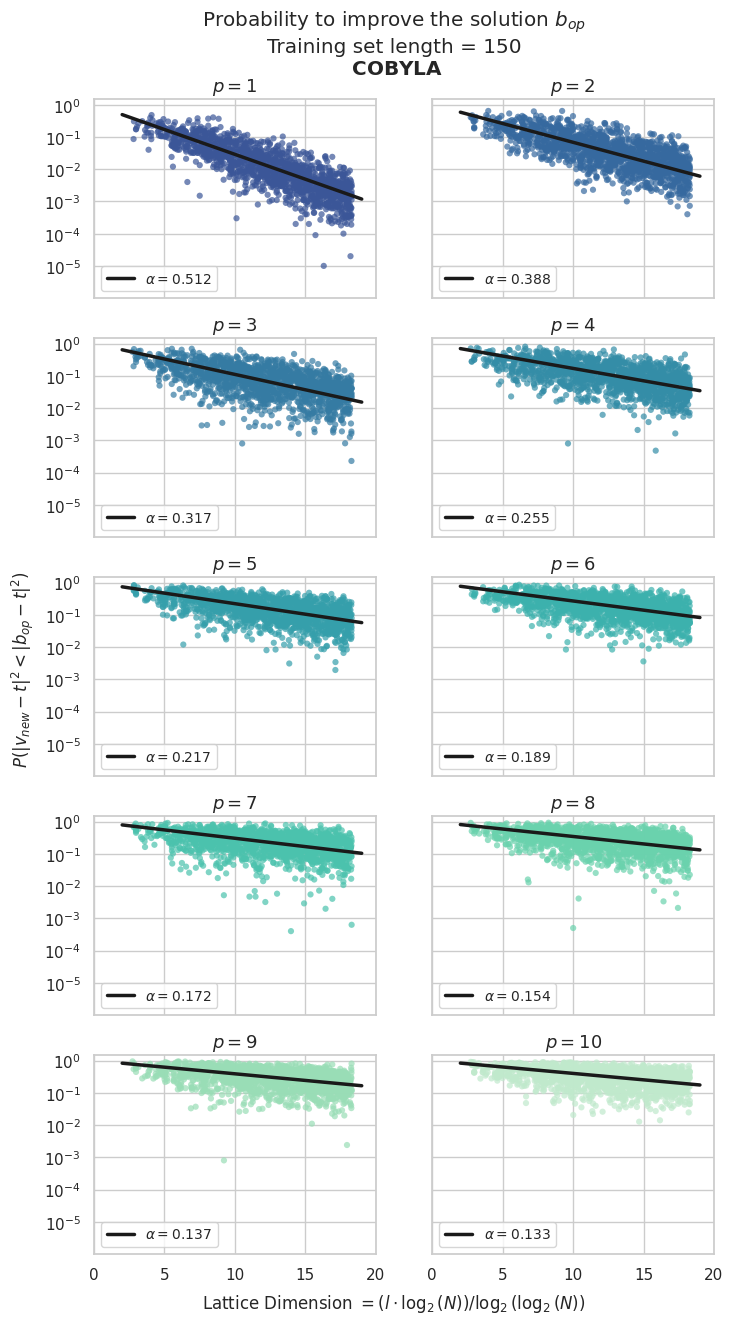

In [114]:
show_data(infile = "./results/scalability_results/datas4200_from9to128_val960_3_COBYLA_p", 
            outfile = "./figures/scalability_datas4200_from9to128_val960_3_COBYLA.png", 
            min_method = "COBYLA", training_set_length=150)

### Escalabilidad para tamaños más grandes

In [115]:
# Alphas del primer entrenamiento
calculate_alphas(infile = "./results/scalability_results/datas4200_from9to128_val240_3_COBYLA_p",
                 outfile = "./results/scalability_alphas/alphas_data4200_val240_COBYLA_3.csv",
                 scal_function= scaling_function)
calculate_alphas(infile = "./results/scalability_results/datas4200_from9to128_val480_3_COBYLA_p",
                 outfile = "./results/scalability_alphas/alphas_data4200_val480_COBYLA_3.csv",
                 scal_function= scaling_function)
calculate_alphas(infile = "./results/scalability_results/datas4200_from9to128_val960_3_COBYLA_p",
                 outfile = "./results/scalability_alphas/alphas_data4200_val960_COBYLA_3.csv",
                 scal_function= scaling_function)

In [116]:
scaling_alphas1 = pd.read_csv("./results/scalability_alphas/alphas_data4200_val240_COBYLA_3.csv")
scaling_alphas2 = pd.read_csv("./results/scalability_alphas/alphas_data4200_val480_COBYLA_3.csv")
scaling_alphas3 = pd.read_csv("./results/scalability_alphas/alphas_data4200_val960_COBYLA_3.csv")


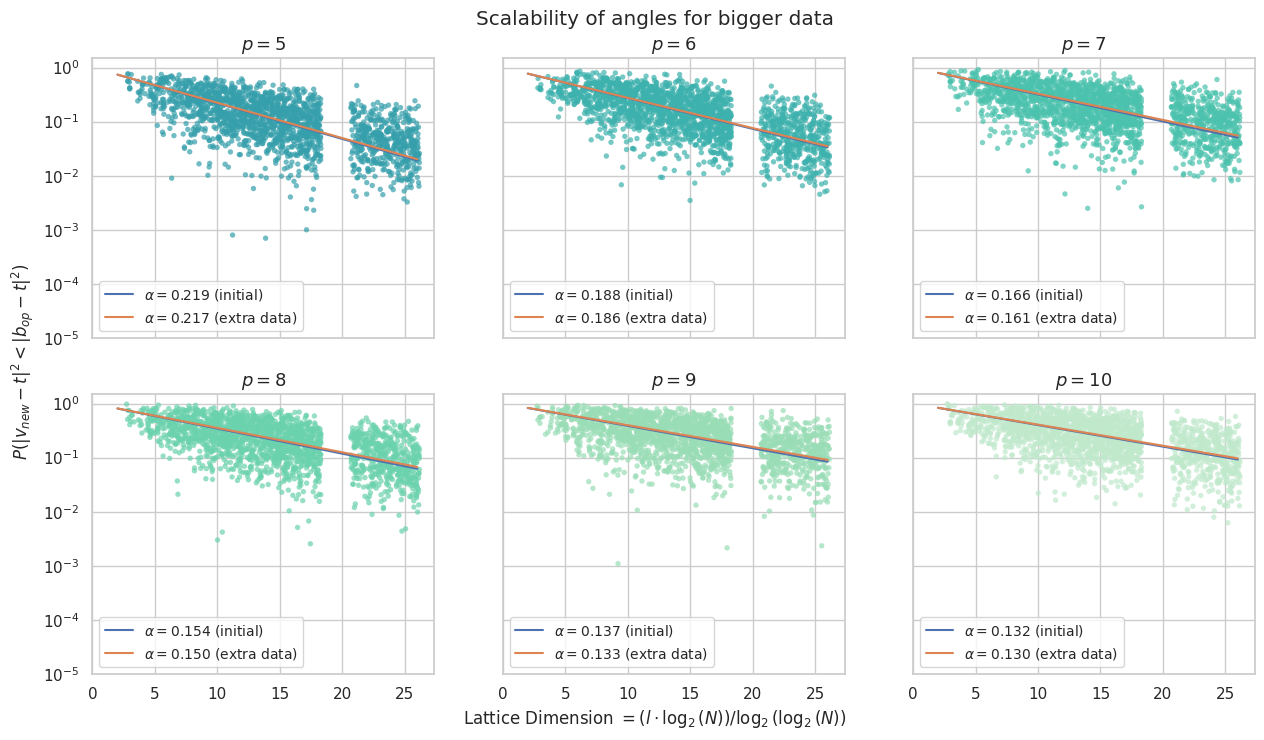

In [117]:
fig, axes = plt.subplots(nrows = 2, ncols = 3, figsize = (15, 8), 
                         sharey = 'row', sharex = 'col')

axes = np.atleast_1d(axes).flatten()

for ax, p in zip(axes, range(5, 11)):
    idx = p - 1
    

    #Cargo los datos de N menores entre 9 y 128 bits
    lower_data_alpha = scaling_alphas1["alpha"][idx]
    data_df = pd.read_csv(f"./results/scalability_results/datas4200_from9to128_val240_3_COBYLA_p{p}.csv")
    lower_data_positive = data_df[data_df["P(|vnew - t|^2 < |b_op - t|^2)"] > 0.0]
    #lower_data_exact_dimension = np.log2(lower_data_positive["N"].to_numpy())/np.log2(np.log2(lower_data_positive["N"].to_numpy()))
    log2_N = np.fromiter((math.log2(int(x)) for x in lower_data_positive["N"]),
                            dtype=float, count=len(lower_data_positive))
    lower_data_exact_dimension = log2_N / np.log2(log2_N)

    #lower_data_lattice_dimension = lower_data_positive["Lattice_dimension"].to_numpy()
    lower_data_probs = lower_data_positive["P(|vnew - t|^2 < |b_op - t|^2)"].to_numpy()

    

    #Cargo los datos de N entre 150 y 200 bits
    extra_df = pd.read_csv(f"./results/scalability_results/datas1020_from150to200_val240_3_COBYLA_p{p}.csv")
    extra_data_positive = extra_df[extra_df["P(|vnew - t|^2 < |b_op - t|^2)"] > 0.0]



    full_data = pd.concat([lower_data_positive, extra_data_positive], ignore_index=True)
    log2_N = np.fromiter((math.log2(int(x)) for x in full_data["N"]),
                     dtype=float, count=len(full_data))
    full_data_exactLat_dimension = log2_N / np.log2(log2_N)
    full_data_probs = full_data["P(|vnew - t|^2 < |b_op - t|^2)"].to_numpy()

    ax.scatter(
            full_data_exactLat_dimension, full_data_probs,
            color=PALETTE[idx], s=15, zorder=2,
            edgecolor = 'none', alpha = 0.7
        )

    full_data_alpha = curve_fit(scaling_function, xdata = full_data_exactLat_dimension, ydata = full_data_probs)[0][0]

    step_size = .1
    xs = np.arange(start=2, stop=26+step_size, step=step_size)
    
    ys_successful = [scaling_function(x, lower_data_alpha) for x in xs]
    sns.lineplot(x=xs, y=ys_successful, ax=ax, 
                 label=f'$\\alpha ={lower_data_alpha:.3f}$ (initial)', linewidth = 1.5)
    
    ys_full_data = [scaling_function(x, full_data_alpha) for x in xs]
    sns.lineplot(x=xs, y=ys_full_data, ax=ax, 
                 label=f'$\\alpha={full_data_alpha:.3f}$ (extra data)', linewidth = 1.5)
    

    ax.legend(fontsize = 10, loc="lower left")
    ax.set_title(rf"$p = {p}$", fontsize=13, fontweight="bold")
    ax.set_xticks(np.arange(0, 30, 5))

    ax.set_yscale("log")
    ax.set_ylim(10**-5, 1.5)
    ax.set_yticks([10**i for i in range(0, -6, -1)])


fig.suptitle(
    "Scalability of angles for bigger data",
    y=0.94
)

fig.supylabel(
        r'$P(|v_{new} - t|^2 < |b_{op} - t|^2)$',
        fontsize=12,
        x=0.07  # ajusta la distancia horizontal al borde izquierdo
    )
fig.supxlabel(
    r'Lattice Dimension $= (l \cdot \log_2(N))/\log_2(\log_2(N))$',
    fontsize=12,
    y=0.04  
)

fig.savefig("./figures/scalability_for_bigger_data_ampl_train3_240.png", dpi=300, bbox_inches='tight')

plt.show()

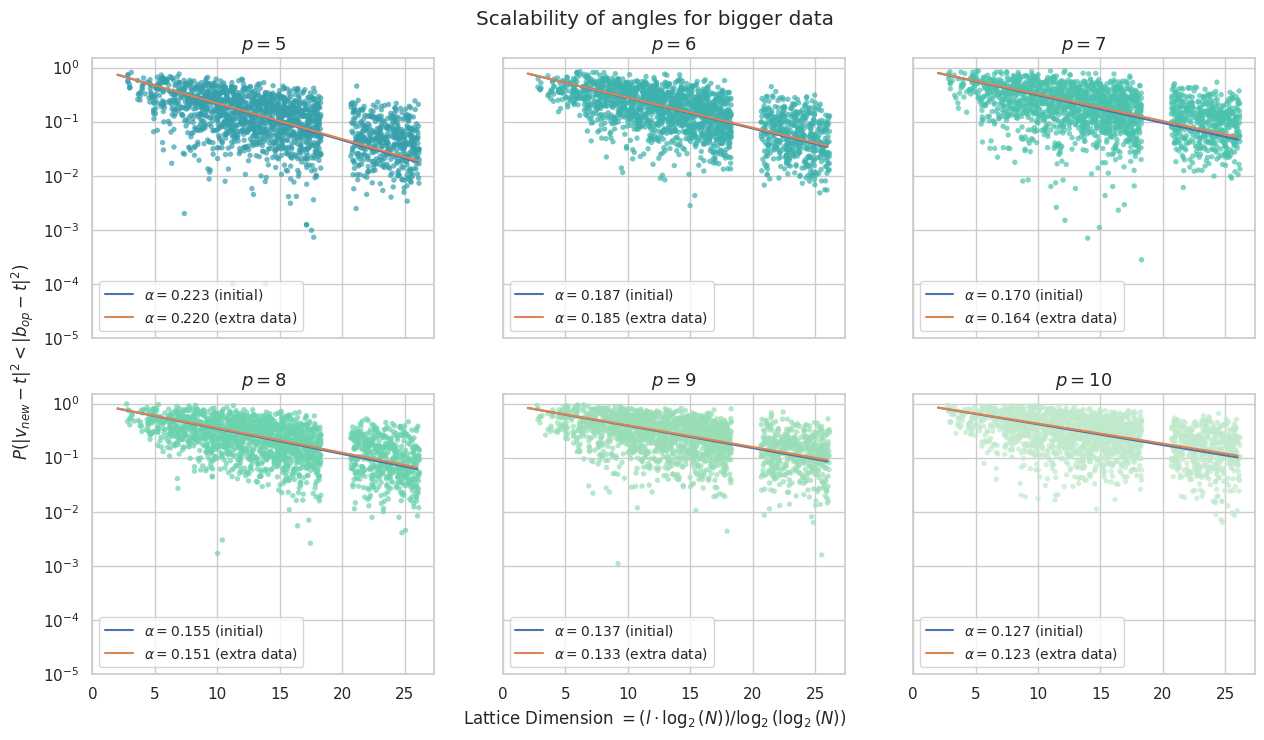

In [118]:
fig, axes = plt.subplots(nrows = 2, ncols = 3, figsize = (15, 8), 
                         sharey = 'row', sharex = 'col')

axes = np.atleast_1d(axes).flatten()

for ax, p in zip(axes, range(5, 11)):
    idx = p - 1
    

    #Cargo los datos de N menores entre 9 y 128 bits
    lower_data_alpha = scaling_alphas2["alpha"][idx]
    data_df = pd.read_csv(f"./results/scalability_results/datas4200_from9to128_val480_3_COBYLA_p{p}.csv")
    lower_data_positive = data_df[data_df["P(|vnew - t|^2 < |b_op - t|^2)"] > 0.0]
    #lower_data_exact_dimension = np.log2(lower_data_positive["N"].to_numpy())/np.log2(np.log2(lower_data_positive["N"].to_numpy()))
    log2_N = np.fromiter((math.log2(int(x)) for x in lower_data_positive["N"]),
                            dtype=float, count=len(lower_data_positive))
    lower_data_exact_dimension = log2_N / np.log2(log2_N)

    #lower_data_lattice_dimension = lower_data_positive["Lattice_dimension"].to_numpy()
    lower_data_probs = lower_data_positive["P(|vnew - t|^2 < |b_op - t|^2)"].to_numpy()

    

    #Cargo los datos de N entre 150 y 200 bits
    extra_df = pd.read_csv(f"./results/scalability_results/datas1020_from150to200_val480_3_COBYLA_p{p}.csv")
    extra_data_positive = extra_df[extra_df["P(|vnew - t|^2 < |b_op - t|^2)"] > 0.0]



    full_data = pd.concat([lower_data_positive, extra_data_positive], ignore_index=True)
    log2_N = np.fromiter((math.log2(int(x)) for x in full_data["N"]),
                     dtype=float, count=len(full_data))
    full_data_exactLat_dimension = log2_N / np.log2(log2_N)
    full_data_probs = full_data["P(|vnew - t|^2 < |b_op - t|^2)"].to_numpy()

    ax.scatter(
            full_data_exactLat_dimension, full_data_probs,
            color=PALETTE[idx], s=15, zorder=2,
            edgecolor = 'none', alpha = 0.7
        )

    full_data_alpha = curve_fit(scaling_function, xdata = full_data_exactLat_dimension, ydata = full_data_probs)[0][0]

    step_size = .1
    xs = np.arange(start=2, stop=26+step_size, step=step_size)
    
    ys_successful = [scaling_function(x, lower_data_alpha) for x in xs]
    sns.lineplot(x=xs, y=ys_successful, ax=ax, 
                 label=f'$\\alpha ={lower_data_alpha:.3f}$ (initial)', linewidth = 1.5)
    
    ys_full_data = [scaling_function(x, full_data_alpha) for x in xs]
    sns.lineplot(x=xs, y=ys_full_data, ax=ax, 
                 label=f'$\\alpha={full_data_alpha:.3f}$ (extra data)', linewidth = 1.5)
    

    ax.legend(fontsize = 10, loc="lower left")
    ax.set_title(rf"$p = {p}$", fontsize=13, fontweight="bold")
    ax.set_xticks(np.arange(0, 30, 5))

    ax.set_yscale("log")
    ax.set_ylim(10**-5, 1.5)
    ax.set_yticks([10**i for i in range(0, -6, -1)])


fig.suptitle(
    "Scalability of angles for bigger data",
    y=0.94
)

fig.supylabel(
        r'$P(|v_{new} - t|^2 < |b_{op} - t|^2)$',
        fontsize=12,
        x=0.07  # ajusta la distancia horizontal al borde izquierdo
    )
fig.supxlabel(
    r'Lattice Dimension $= (l \cdot \log_2(N))/\log_2(\log_2(N))$',
    fontsize=12,
    y=0.04  
)

fig.savefig("./figures/scalability_for_bigger_data_ampl_train3_480.png", dpi=300, bbox_inches='tight')

plt.show()

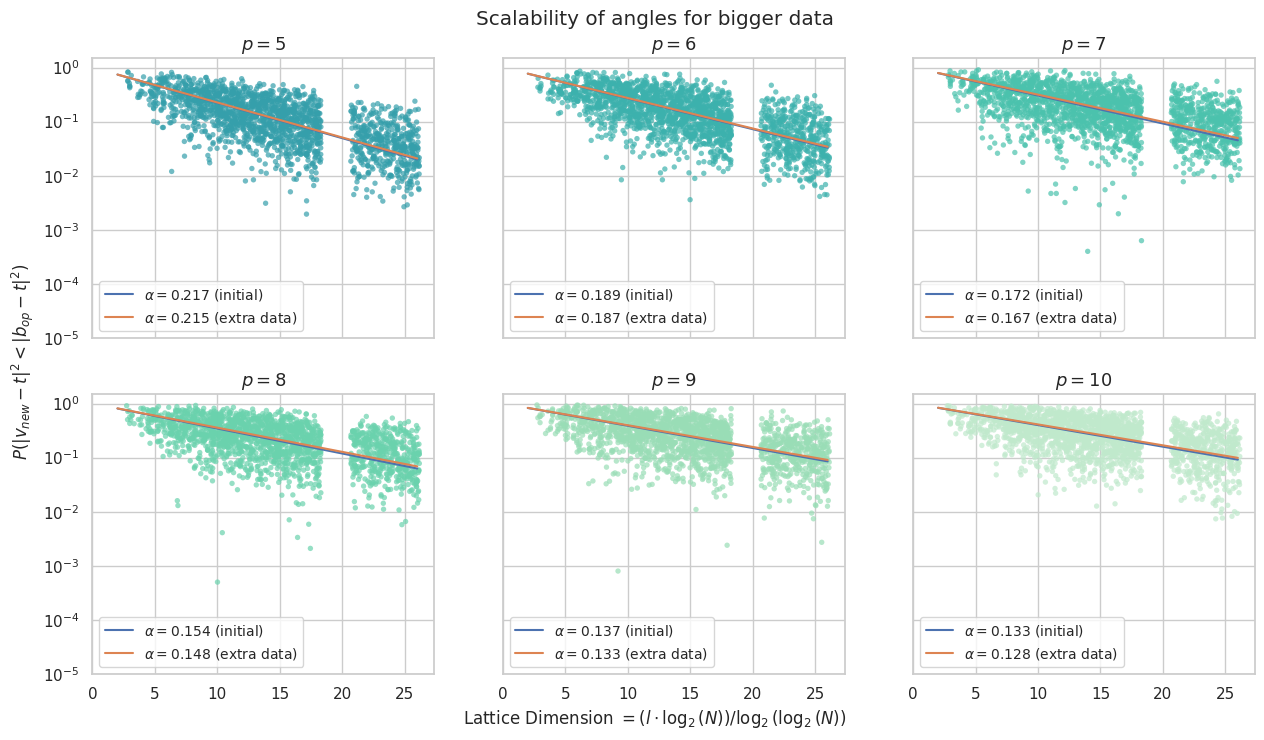

In [119]:
fig, axes = plt.subplots(nrows = 2, ncols = 3, figsize = (15, 8), 
                         sharey = 'row', sharex = 'col')

axes = np.atleast_1d(axes).flatten()

for ax, p in zip(axes, range(5, 11)):
    idx = p - 1
    

    #Cargo los datos de N menores entre 9 y 128 bits
    lower_data_alpha = scaling_alphas3["alpha"][idx]
    data_df = pd.read_csv(f"./results/scalability_results/datas4200_from9to128_val960_3_COBYLA_p{p}.csv")
    lower_data_positive = data_df[data_df["P(|vnew - t|^2 < |b_op - t|^2)"] > 0.0]
    #lower_data_exact_dimension = np.log2(lower_data_positive["N"].to_numpy())/np.log2(np.log2(lower_data_positive["N"].to_numpy()))
    log2_N = np.fromiter((math.log2(int(x)) for x in lower_data_positive["N"]),
                            dtype=float, count=len(lower_data_positive))
    lower_data_exact_dimension = log2_N / np.log2(log2_N)

    #lower_data_lattice_dimension = lower_data_positive["Lattice_dimension"].to_numpy()
    lower_data_probs = lower_data_positive["P(|vnew - t|^2 < |b_op - t|^2)"].to_numpy()

    

    #Cargo los datos de N entre 150 y 200 bits
    extra_df = pd.read_csv(f"./results/scalability_results/datas1020_from150to200_val960_3_COBYLA_p{p}.csv")
    extra_data_positive = extra_df[extra_df["P(|vnew - t|^2 < |b_op - t|^2)"] > 0.0]



    full_data = pd.concat([lower_data_positive, extra_data_positive], ignore_index=True)
    log2_N = np.fromiter((math.log2(int(x)) for x in full_data["N"]),
                     dtype=float, count=len(full_data))
    full_data_exactLat_dimension = log2_N / np.log2(log2_N)
    full_data_probs = full_data["P(|vnew - t|^2 < |b_op - t|^2)"].to_numpy()

    ax.scatter(
            full_data_exactLat_dimension, full_data_probs,
            color=PALETTE[idx], s=15, zorder=2,
            edgecolor = 'none', alpha = 0.7
        )

    full_data_alpha = curve_fit(scaling_function, xdata = full_data_exactLat_dimension, ydata = full_data_probs)[0][0]

    step_size = .1
    xs = np.arange(start=2, stop=26+step_size, step=step_size)
    
    ys_successful = [scaling_function(x, lower_data_alpha) for x in xs]
    sns.lineplot(x=xs, y=ys_successful, ax=ax, 
                 label=f'$\\alpha ={lower_data_alpha:.3f}$ (initial)', linewidth = 1.5)
    
    ys_full_data = [scaling_function(x, full_data_alpha) for x in xs]
    sns.lineplot(x=xs, y=ys_full_data, ax=ax, 
                 label=f'$\\alpha={full_data_alpha:.3f}$ (extra data)', linewidth = 1.5)
    

    ax.legend(fontsize = 10, loc="lower left")
    ax.set_title(rf"$p = {p}$", fontsize=13, fontweight="bold")
    ax.set_xticks(np.arange(0, 30, 5))

    ax.set_yscale("log")
    ax.set_ylim(10**-5, 1.5)
    ax.set_yticks([10**i for i in range(0, -6, -1)])


fig.suptitle(
    "Scalability of angles for bigger data",
    y=0.94
)

fig.supylabel(
        r'$P(|v_{new} - t|^2 < |b_{op} - t|^2)$',
        fontsize=12,
        x=0.07  # ajusta la distancia horizontal al borde izquierdo
    )
fig.supxlabel(
    r'Lattice Dimension $= (l \cdot \log_2(N))/\log_2(\log_2(N))$',
    fontsize=12,
    y=0.04  
)

fig.savefig("./figures/scalability_for_bigger_data_ampl_train3_960.png", dpi=300, bbox_inches='tight')

plt.show()